<a href="https://colab.research.google.com/github/hirdeshkumar2407/NMDA-FP/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1: Setup and Config**

In [ ]:
import gc
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial import cKDTree, KDTree
from tqdm.auto import tqdm
import joblib

# ── scikit‑learn ──
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression, Ridge

# ── RAPIDS cuML (GPU Random Forest) ──
import cupy as cp
from cuml.ensemble import RandomForestClassifier as cuRFClassifier
from cuml.ensemble import RandomForestRegressor as cuRFRegressor

# ── PyTorch ──
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

CPU_WORKERS = os.cpu_count() or -1
print(f"CPU workers: {CPU_WORKERS}")

CPU workers: 4


In [2]:
pwd

'/kaggle/working'

In [3]:
# ── Kaggle paths & runtime switches ─────────────────────────────

input_root = "/kaggle/input/datasets/hammadsyarif/l5ghdd-ds"
acc_arena = os.path.join(input_root, "Acc Arena")
working = "/kaggle/working"

master_df = "master_quantile_full_one_min_df.parquet"
engineered_df = "arena_quantile_full_one_min_df.parquet"

cached_master = os.path.join(working, master_df)
cached_feat = os.path.join(working, engineered_df)

ds_master = os.path.join(input_root, master_df)
ds_feat = os.path.join(input_root, engineered_df)

fast_mode = True          # smaller models / optional subsampling
run_sequence_model = False  # CNN+GRU is slow; enable when RF baseline works
random_state = 42

print("INPUT_ROOT:", input_root)
print("Exists:", os.path.isdir(input_root))
print("FAST_MODE:", fast_mode)


INPUT_ROOT: /kaggle/input/datasets/hammadsyarif/l5ghdd-ds
Exists: True
FAST_MODE: True


In [ ]:
# ── GPU RF backend (optional) ───────────────────────────────────
try:
    USE_GPU_RF = True
    print("Backend: GPU Random Forest (cuML)")
except Exception as e:
    cp = None
    USE_GPU_RF = False
    print("Backend: CPU Random Forest (sklearn)")
    print(e)

def clear_memory():
    gc.collect()
    if cp is not None:
        try:
            cp.get_default_memory_pool().free_all_blocks()
        except Exception:
            pass

def to_numpy(x):
    if cp is not None and isinstance(x, cp.ndarray):
        return cp.asnumpy(x)
    return np.asarray(x)

Backend: GPU Random Forest (cuML)


In [6]:
#print(f"User query: 'the notebook is made first 500 users and lets try include rest 12000 users'")
#print(f"To include data for all 12000 users, we need to process files for User IDs from 0 to 11999.")
#print(f"These are typically split into chunks of 500 users per file.")

# Further reducing max_user_id from 5999 to 999 to process 1000 users (0-999)
max_user_id = 11999
chunk_size = 500

# List of subdirectories containing the metric files
data_subdirs = {
    "Positions": f"{acc_arena}/Positions_Acc_Arena/",
    "Throughput": f"{acc_arena}/Throughput_Acc_Arena/",
    "SINRUL": f"{acc_arena}/SINR_Acc_Arena/",
    "SINRDL": f"{acc_arena}/SINR_Acc_Arena/",
    "PRB": f"{acc_arena}/PRB_Acc_Arena/",
    "RU": f"{acc_arena}/RU_Association_Acc_Arena/",
    "BLER": f"{acc_arena}/BLER_Acc_Arena/"
}

# Base filename patterns for each metric, extracted from the notebook's existing loading logic
file_patterns = {
    "Positions": "Positions_Salt_Tar_UE_Id_",
    "Throughput": "Throughput_UE_Id_",
    "SINRUL": "SINRUL_UE_Id_",
    "SINRDL": "SINRDL_UE_Id_",
    "PRB": "PRBS_UE_Id_",
    "RU": "RU_UE_Id_",
    "BLER": "BLER_UE_Id_"
}

all_files_to_process = []

for metric_name, subdir in data_subdirs.items():
    print(f"\n--- Listing {metric_name} files in {subdir} ---")
    for start_id in range(0, max_user_id + 1, chunk_size):
        end_id = start_id + chunk_size - 1
        if end_id > max_user_id:
            end_id = max_user_id

        filename_prefix = file_patterns[metric_name]
        filename = f"{filename_prefix}{start_id}_{end_id}.csv"

        # Paths are relative to DATASET_PATH because os.chdir(DATASET_PATH) was called in an earlier cell.
        expected_file_path = os.path.join(subdir, filename)
        all_files_to_process.append(expected_file_path)
        print(expected_file_path)

print(f"\nIn total, {len(all_files_to_process)} files are expected to be processed for all {max_user_id + 1} users.")
print(f"The next step would involve modifying cells that load data (e.g., cell `fp3mSLPLAj2h` and `dyWc1dl6GqgQ`)")
print(f"to iterate through these file patterns and concatenate the resulting dataframes.")


--- Listing Positions files in /kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/ ---
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_0_499.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_500_999.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_1000_1499.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_1500_1999.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_2000_2499.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_2500_2999.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_3000_3499.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Sa

## **2: Data Preprocessing**

For the inital phase, we are cosidering 500 user from Salt & Tar out of 3000.

###**2.1: Dataset Cleaning and Construction**

This cell handles standard files `(Throughput, SINR, PRB, RU, BLER)` by melting them and stripping out the *entityStats id* text so we are left with pure integers.

In [7]:
def flatten_metric(file_path, feature_name):
    df = pd.read_csv(file_path)
    df_long = df.melt(id_vars=['time'], var_name='User_String', value_name=feature_name)
    df_long.rename(columns={'time': 'Timestamp'}, inplace=True)
    df_long['User_ID'] = df_long['User_String'].str.replace('entityStats id ', '').astype('int32')
    return df_long[['Timestamp', 'User_ID', feature_name]]

In [ ]:
DATASET_PATH = input_root  # Ensure this variable is active in your notebook
max_user_id = 11999                 # 12,000 users total (0-11999)
chunk_size = 500

if os.path.exists(cached_master):
    print("⚡ Loading master_df from cache ...")
    master_df = pd.read_parquet(cached_master)
elif os.path.exists(ds_master):
    print("⚡ Loading master_df from datasets ...")
    master_df = pd.read_parquet(ds_master)
else:
    # ==========================================
    # 1. GLOBAL SETTINGS & INITIALIZATION
    # ==========================================
    aggregated_chunks = []
    global_origin_lat = None
    global_origin_lon = None
    
    print(f"🚀 Starting ultra-lean ingestion for {max_user_id + 1} users...")
    
    # ==========================================
    # 2. THE ISOLATED CHUNK LOOP
    # ==========================================
    for start_id in range(0, max_user_id + 1, chunk_size):
        end_id = min(start_id + chunk_size - 1, max_user_id)
        print(f"🔄 Processing file chunk: Users {start_id} to {end_id}...")
    
        # --- A. Construct File Paths ---
        base_dir = os.path.join(DATASET_PATH, acc_arena)
        tp_path      = os.path.join(base_dir, "Throughput_Acc_Arena", f"Throughput_UE_Id_{start_id}_{end_id}.csv")
        sinr_ul_path = os.path.join(base_dir, "SINR_Acc_Arena", f"SINRUL_UE_Id_{start_id}_{end_id}.csv")
        sinr_dl_path = os.path.join(base_dir, "SINR_Acc_Arena", f"SINRDL_UE_Id_{start_id}_{end_id}.csv")
        prb_path     = os.path.join(base_dir, "PRB_Acc_Arena", f"PRBS_UE_Id_{start_id}_{end_id}.csv")
        ru_path      = os.path.join(base_dir, "RU_Association_Acc_Arena", f"RU_UE_Id_{start_id}_{end_id}.csv")
        bler_path    = os.path.join(base_dir, "BLER_Acc_Arena", f"BLER_UE_Id_{start_id}_{end_id}.csv")
        pos_path     = os.path.join(base_dir, "Positions_Acc_Arena", f"Positions_Salt_Tar_UE_Id_{start_id}_{end_id}.csv")
    
        # --- B. Load and Preprocess Metrics ---
        metrics = [
            (tp_path, "Throughput"),
            (sinr_ul_c := flatten_metric(sinr_ul_path, "SINR_UL"), "SINR_UL"), # Actually keep as variables
        ]
        # (Keeping your original explicit load pattern for safety)
        tp_c      = flatten_metric(tp_path, "Throughput").drop_duplicates(subset=['Timestamp', 'User_ID'])
        sinr_ul_c = flatten_metric(sinr_ul_path, "SINR_UL").drop_duplicates(subset=['Timestamp', 'User_ID'])
        sinr_dl_c = flatten_metric(sinr_dl_path, "SINR_DL").drop_duplicates(subset=['Timestamp', 'User_ID'])
        prb_c     = flatten_metric(prb_path, "PRB").drop_duplicates(subset=['Timestamp', 'User_ID'])
        ru_c      = flatten_metric(ru_path, "RU").drop_duplicates(subset=['Timestamp', 'User_ID'])
        bler_c    = flatten_metric(bler_path, "BLER").drop_duplicates(subset=['Timestamp', 'User_ID'])
    
        # --- C. Process Positions Matrix ---
        df_pos_raw = pd.read_csv(pos_path)
        raw_matrix = df_pos_raw.values
        
        timestamps = raw_matrix[:, 0]
        data_matrix = raw_matrix[:, 1:]
        
        # Reshape and Flatten
        num_timestamps = len(timestamps)
        num_users_in_chunk = end_id - start_id + 1
        reshaped_pos = data_matrix.reshape(num_timestamps, num_users_in_chunk, 5)
        
        records = [
            [int(timestamps[t]), int(reshaped_pos[t, u, 0]), *reshaped_pos[t, u, 1:]]
            for t in range(num_timestamps)
            for u in range(num_users_in_chunk)
        ]
        
        pos_c = pd.DataFrame(records, columns=['Timestamp', 'User_ID', 'Latitude', 'Longitude', 'Altitude', 'MobileState'])
    
        # Set Global Origin for Cartesian conversion
        if global_origin_lat is None:
            global_origin_lat = pos_c['Latitude'].iloc[0]
            global_origin_lon = pos_c['Longitude'].iloc[0]
            LAT_TO_M = 111320.0
            LON_TO_M = 111320.0 * np.cos(np.radians(global_origin_lat))
        
        pos_c['X_meters'] = (pos_c['Longitude'] - global_origin_lon) * LON_TO_M
        pos_c['Y_meters'] = (pos_c['Latitude'] - global_origin_lat) * LAT_TO_M
        pos_c = pos_c.drop_duplicates(subset=['Timestamp', 'User_ID'])
    
        # --- D. Merge All Metrics ---
        chunk_df = (pos_c.merge(tp_c,      on=['Timestamp', 'User_ID'], how='inner')
                         .merge(sinr_ul_c, on=['Timestamp', 'User_ID'], how='inner')
                         .merge(sinr_dl_c, on=['Timestamp', 'User_ID'], how='inner')
                         .merge(prb_c,     on=['Timestamp', 'User_ID'], how='inner')
                         .merge(ru_c,      on=['Timestamp', 'User_ID'], how='inner')
                         .merge(bler_c,    on=['Timestamp', 'User_ID'], how='inner'))
    
        # ==========================================
        # 3. FAST 15-SECOND AGGREGATION
        # ==========================================
        chunk_df['Timestamp_DT'] = pd.to_datetime(chunk_df['Timestamp'], unit='s')
        gb = chunk_df.set_index('Timestamp_DT').groupby('User_ID')
    
        # 1. Base Aggregation (Fast)
        fast_rules = {
            'Latitude': 'mean', 'Longitude': 'mean', 'Altitude': 'mean',
            'X_meters': 'mean', 'Y_meters': 'mean',
            'SINR_UL': 'mean', 'SINR_DL': 'mean',
            'BLER': 'mean', 'RU': 'first', 'MobileState': 'first'
        }
        chunk_agg = gb.resample('60S').agg(fast_rules).dropna().reset_index()
    
        # 2. Add Quantiles (Optimized Vectorized)
        q_tp   = gb.resample('60S')['Throughput'].quantile(0.95).reset_index(name='Throughput')
        q_prb  = gb.resample('60S')['PRB'].quantile(0.95).reset_index(name='PRB')
        q_sinr = gb.resample('60S')['SINR_UL'].quantile(0.90).reset_index(name='SINR_UL_q90')
        q_bler = gb.resample('60S')['BLER'].quantile(0.10).reset_index(name='BLER_q10')
    
        # 3. Merge quantiles back
        chunk_agg = (chunk_agg.merge(q_tp,   on=['User_ID', 'Timestamp_DT'])
                              .merge(q_prb,  on=['User_ID', 'Timestamp_DT'])
                              .merge(q_sinr, on=['User_ID', 'Timestamp_DT'])
                              .merge(q_bler, on=['User_ID', 'Timestamp_DT']))
    
        # 4. Final Formatting & Downcasting
        float_cols = ['Latitude', 'Longitude', 'Altitude', 'X_meters', 'Y_meters', 
                      'Throughput', 'SINR_UL', 'SINR_DL', 'PRB', 'BLER',
                      'SINR_UL_q90', 'BLER_q10']
        
        chunk_agg[float_cols] = chunk_agg[float_cols].astype('float32')
        chunk_agg['User_ID']     = chunk_agg['User_ID'].astype('int32')
        chunk_agg['RU']          = chunk_agg['RU'].astype('int8')
        chunk_agg['MobileState'] = chunk_agg['MobileState'].astype('int8')
    
        aggregated_chunks.append(chunk_agg)
        
        # ==========================================
        # 4. EXPLICIT RAM CLEANUP (Crucial for 30GB Limit)
        # ==========================================
        del chunk_df, pos_c, tp_c, sinr_ul_c, sinr_dl_c, prb_c, ru_c, bler_c, df_pos_raw, raw_matrix, reshaped_pos, records
        gc.collect()  # Forces Python to immediately release the memory back to your OS
    
    # ==========================================
    # 5. COMPILE FINAL MASTER DATASET
    # ==========================================
    master_df = pd.concat(aggregated_chunks, ignore_index=True)
    master_df.rename(columns={'Timestamp_DT': 'Timestamp'}, inplace=True)
    master_df.to_parquet(cached_master, index=False)
    print("\n🎉 Success! Master dataset successfully extracted and compressed!")
    print(f"Final 60-Second Aggregated Shape: {master_df.shape}")

⚡ Loading master_df from datasets ...


In [9]:
# 1. Strip away any duplicate columns
master_df = master_df.loc[:, ~master_df.columns.duplicated()].copy()
cols_to_drop = [col for col in ['Timestamp', 'index', 'level_0'] if col in master_df.columns]
master_df.drop(columns=cols_to_drop, inplace=True)

# 2. Reconstruct the accurate 15-second time gaps
master_df['Timestamp_Sec'] = master_df.groupby('User_ID').cumcount() * 60

# 3. Reorder the columns
cols = ['Timestamp_Sec', 'User_ID'] + [c for c in master_df.columns if c not in ['Timestamp_Sec', 'User_ID']]
master_df = master_df[cols]

In [10]:
master_df.shape

(6564000, 16)

In [11]:
master_df.head(30)

,Timestamp_Sec,User_ID,Latitude,Longitude,Altitude,X_meters,Y_meters,SINR_UL,SINR_DL,BLER,RU,MobileState,Throughput,PRB,SINR_UL_q90,BLER_q10
0,0,0,53.395084,-2.992707,3.581009,0.0,0.0,-14.772825,-14.135747,0.813364,26,2,8.352800,33.700001,-10.496062,0.428805
1,60,0,53.395084,-2.992707,3.581009,0.0,0.0,-16.963371,-16.852478,0.743953,26,2,1.079200,37.150002,-12.073236,0.301559
2,120,0,53.395084,-2.992707,3.581009,0.0,0.0,-14.323143,-13.703755,0.576724,26,2,1.148800,34.299999,-10.814339,0.002990
3,180,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.458859,-10.417394,0.219680,26,2,1.289600,33.299999,-7.676000,0.000298
4,240,0,53.395084,-2.992707,3.581009,0.0,0.0,-9.672252,-9.366496,0.204938,26,2,1.364800,35.150002,-8.087138,0.006283
5,300,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.464019,-10.129985,0.189375,26,2,1.136800,29.450001,-7.572224,0.005700
6,360,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.004877,-9.809793,0.165452,26,2,5.279200,34.000000,-7.312283,0.003596
7,420,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.476074,-9.944695,0.255898,26,2,5.476000,37.000000,-8.217306,0.000459
8,480,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.385905,-10.148302,0.220332,26,2,1.423200,36.750000,-7.763103,0.002366
9,540,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.951180,-10.751991,0.182759,26,2,1.392000,36.299999,-8.140181,0.004695


### **2.2: Exploratory Data Analysis**

In [ ]:
# Descriptive summary statistics
print("Descriptive statistics")
core_metrics = ['Throughput', 'SINR_UL', 'PRB', 'BLER']
summary_stats = master_df[core_metrics].describe()

# Add a row tracking the exact percentage of hard zero values in each column
zeros_pct = (master_df[core_metrics] == 0).sum() / len(master_df) * 100
summary_stats.loc['zeros_percentage'] = zeros_pct

print("\n=== DATASET STATISTICAL MATRIX ===")
print(summary_stats)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Distribution Profiles of Core 5G Wireless Metrics (ACC Arena)', fontsize=16, fontweight='bold')

# Throughput Distribution
sns.histplot(data=master_df, x='Throughput', bins=50, ax=axes[0,0], color='royalblue', kde=False)
axes[0,0].set_title('User Throughput Distribution (Mbps)', fontsize=12)
axes[0,0].set_yscale('log') # Log scale prevents 0-value peaks from hiding everything else
axes[0,0].set_ylabel('Log Count')

# SINR Uplink Distribution
sns.histplot(data=master_df, x='SINR_UL', bins=50, ax=axes[0,1], color='forestgreen', kde=False)
axes[0,1].set_title('SINR Uplink Distribution (dB)', fontsize=12)
axes[0,1].set_ylabel('Count')

# Physical Resource Blocks (PRB) Distribution
sns.histplot(data=master_df, x='PRB', bins=30, ax=axes[1,0], color='darkorange', kde=False)
axes[1,0].set_title('PRB Allocation Profile', fontsize=12)
axes[1,0].set_yscale('log')
axes[1,0].set_ylabel('Log Count')

# Block Error Rate (BLER) Distribution
sns.histplot(data=master_df, x='BLER', bins=50, ax=axes[1,1], color='crimson', kde=False)
axes[1,1].set_title('Block Error Rate (BLER) Profile', fontsize=12)
axes[1,1].set_yscale('log')
axes[1,1].set_ylabel('Log Count')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# Select the numeric attributes we want to check for patterns
corr_features = ['X_meters', 'Y_meters', 'Throughput', 'SINR_UL', 'SINR_DL', 'PRB', 'RU', 'BLER', 'MobileState']
corr_matrix = master_df[corr_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Raw Wireless & Spatial Attributes', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
# 1. Count exactly how many records are connected to each individual Radio Unit
ru_counts = master_df['RU'].value_counts().sort_index()
ru_percentages = master_df['RU'].value_counts(normalize=True).sort_index() * 100

print("\n=== RADIO UNIT CONNECTION DISTRIBUTION ===")
for ru_id in ru_counts.index:
    print(f"📡 Radio Unit {ru_id}: {ru_counts[ru_id]:,} connections ({ru_percentages[ru_id]:.2f}%)")

# 2. Visualize the categorical load balancing using a Bar Chart
plt.figure(figsize=(10, 5))
sns.countplot(data=master_df, x='RU', palette='viridis')
plt.title('Network Load Balancing: Connection Counts per Radio Unit (RU)', fontsize=14, fontweight='bold')
plt.xlabel('Radio Unit (RU) ID Index')
plt.ylabel('Total Allocated Sample Points')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 1. Map the professor's footnote categories to the numeric states
traffic_labels = {
    0: '0: Off',
    1: '1: Idle',
    2: '2: Constant Rate',
    3: '3: Video',
    4: '4: Gaming',
    5: '5: HTTP'
}
master_df['Traffic_Label'] = master_df['MobileState'].map(traffic_labels)

# 2. Print absolute composition metrics
traffic_counts = master_df['Traffic_Label'].value_counts().sort_index()
traffic_pct = master_df['Traffic_Label'].value_counts(normalize=True).sort_index() * 100

print("\n=== TRAFFIC MIX COMPOSITION MATRIX ===")
for label in traffic_counts.index:
    print(f" {label:<18} -> {traffic_counts[label]:>9,} rows ({traffic_pct[label]:.2f}%)")

# 3. Visualize Behavior: How does Traffic Class change Throughput?
plt.figure(figsize=(14, 6))

# Subplot 1: Volume of rows per traffic type
plt.subplot(1, 2, 1)
sns.countplot(data=master_df, x='Traffic_Label', palette='Set2', order=sorted(traffic_labels.values()))
plt.title('Dataset Volume by Traffic Class', fontsize=12, fontweight='bold')
plt.xlabel('Application Profile')
plt.ylabel('Total Sample Count')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Subplot 2: Average Throughput per traffic type
plt.subplot(1, 2, 2)
sns.barplot(data=master_df, x='Traffic_Label', y='Throughput', palette='Set2', order=sorted(traffic_labels.values()), errorbar=None)
plt.title('Mean Throughput by Traffic Class', fontsize=12, fontweight='bold')
plt.xlabel('Application Profile')
plt.ylabel('Average Throughput (Mbps)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

* **The Idle Dominance:** The network environment is heavily skewed by non-active background traffic, where **State 1 (Idle)** accounts for **18,348,571 rows (70.01% of total volume)**.
* **Active State Sparsity:** High-impact, bursty application states that heavily load physical resources—such as **State 3 (Video Streaming, 0.90%)** and **State 4 (Gaming, 0.64%)**—are deeply buried in noise.

In [ ]:
master_df.head(50)

In [ ]:
# 1. Isolate a single synchronized timestamp to view a clean spatial snapshot
# Timestamp 1215 contains all 500 active users tracked simultaneously
snapshot_df = master_df[master_df['Timestamp_Sec'] == 60]

# 2. Generate the spatial scatter plot
plt.figure(figsize=(12, 9))

# Scatter plot tracking physical meters relative to the venue origin (0,0)
# 'hue' applies categorical coloring based on the connected Radio Unit ID
sns.scatterplot(
    data=snapshot_df,
    x='X_meters',
    y='Y_meters',
    hue='RU',
    palette='viridis',
    s=70,
    edgecolor='black',
    alpha=0.85
)

# Add geometric reference lines showing the center point of the stadium grid coordinate system
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Formatting titles and axes labels
plt.title('Spatial Topography Snapshot: User Locations & Antenna Sectors (t = 15)', fontsize=14, fontweight='bold')
plt.xlabel('Horizontal Distance from Origin (X meters)', fontsize=11)
plt.ylabel('Vertical Distance from Origin (Y meters)', fontsize=11)

# Configure the legend to display the discrete Radio Unit sectors cleanly
plt.legend(title='Connected Radio Unit (RU)', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### **2.3: Feature Engineering**

In [ ]:
def engineer_acc_arena_features(df):
    """
    Executes advanced multi-domain feature engineering for the ACC Arena dataset.
    Optimized for memory efficiency and handles dynamic user dropouts safely.
    """
    print("Initiating Advanced Feature Engineering Pipeline...")
    feat_df = df.copy()

    # Identify correct time column based on our previous timeline fixes
    time_col = 'Timestamp_Sec' if 'Timestamp_Sec' in feat_df.columns else 'Timestamp'

    # CRITICAL: Sort by User_ID first to ensure perfect trajectory math
    feat_df = feat_df.sort_values(by=['User_ID', time_col]).reset_index(drop=True)

    # ----------------------------------------------------
    # DOMAIN 1: RADIO & LINK PHYSICS
    # ----------------------------------------------------
    print(" Engineering Radio Domain features...")
    print(" Regressing the max throughput...")

    # >0.9 linearity with SINR_UL
    feat_df.drop(columns=["SINR_DL"], inplace=True)

    # 4. Generate the Physics-Informed Robust Signal Feature
    feat_df['SINR_Linear_q90'] = (10 ** (feat_df['SINR_UL_q90'] / 10.0)).astype(np.float32)
    
    feat_df['Effective_Signal_Robust'] = np.clip(
        feat_df['SINR_Linear_q90'] / (feat_df['BLER_q10'] + 1e-4), 0, 1e6
    ).astype(np.float32)
    
    feat_df['Log_Effective_Signal_Robust'] = np.log1p(
        feat_df['Effective_Signal_Robust']
    ).astype(np.float32)

    # ----------------------------------------------------
    # DOMAIN 2: INFRASTRUCTURE CONGESTION
    # ----------------------------------------------------
    print(" Calculating Real-Time Radio Unit Load...")
    feat_df['RU_Current_Load'] = feat_df.groupby([time_col, 'RU'])['User_ID'].transform('count').astype(np.int16)

    # ----------------------------------------------------
    # DOMAIN 3: TEMPORAL & SPATIAL MOBILITY
    # ----------------------------------------------------
    print(" Computing Kinematic Vectors...")
    # 1215 subtraction removed: Timeline is already correctly zero-based!
    
    user_groups = feat_df.groupby('User_ID')
    feat_df['Delta_X'] = user_groups['X_meters'].diff().fillna(0).astype(np.float32)
    feat_df['Delta_Y'] = user_groups['Y_meters'].diff().fillna(0).astype(np.float32)
    feat_df['Velocity'] = np.sqrt(feat_df['Delta_X']**2 + feat_df['Delta_Y']**2).astype(np.float32)

    print(" Vectorizing Multi-Scale Local Crowd Density (cKDTree)...")
    radii = [2.0, 5.0, 10.0]
    density_results = {r: np.zeros(len(feat_df), dtype=np.int16) for r in radii}

    grouped_time = feat_df.groupby(time_col)
    
    # cKDTree easily handles missing users without crashing
    for t, group in tqdm(grouped_time, desc="Mapping Densities"):
        coords = group[['X_meters', 'Y_meters']].values
        tree = cKDTree(coords)
        for r in radii:
            counts = np.array([len(neighbors) - 1 for neighbors in tree.query_ball_point(coords, r)])
            density_results[r][group.index] = counts

    feat_df['Crowd_Density_2m'] = density_results[2.0]
    feat_df['Crowd_Density_5m'] = density_results[5.0]
    feat_df['Crowd_Density_10m'] = density_results[10.0]

    # ----------------------------------------------------
    # DOMAIN 4: APPLICATION BEHAVIOR
    # ----------------------------------------------------
    print(" Decoding Application States...")
    state_dummies = pd.get_dummies(feat_df['MobileState'], prefix='State').astype(np.int8)
    feat_df = pd.concat([feat_df, state_dummies], axis=1)

    feat_df['Resource_Efficiency'] = (feat_df['PRB'] * (feat_df['MobileState'] != 1)).astype(np.float32)

    # ----------------------------------------------------
    # MEMORY & INTEGRITY AUDIT
    # ----------------------------------------------------
    print("\n Finalizing Memory Cleanup Audit...")
    feat_df.drop(columns=['Delta_X', 'Delta_Y'], inplace=True)

    final_mem = feat_df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f" Engineering Complete! Dataframe Shape: {feat_df.shape}")
    print(f" Memory Footprint: {final_mem:.2f} MB")

    return feat_df

In [13]:
if os.path.exists(cached_feat):
    print("Loading processed cache...")
    arena_featured_df = pd.read_parquet(cached_feat)
elif os.path.exists(ds_feat):
    print("Loading processed from input ds...")
    arena_featured_df = pd.read_parquet(ds_feat)
else:
    print("No checkpoint found. Running feature engineering...")
    arena_featured_df = engineer_acc_arena_features(master_df)
    arena_featured_df.to_parquet(cached_feat, index=False)
    print("Checkpoint saved.")

Loading processed from input ds...


In [14]:
arena_featured_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6564000 entries, 0 to 6563999
Data columns (total 31 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Timestamp_Sec                int64  
 1   User_ID                      int32  
 2   Latitude                     float32
 3   Longitude                    float32
 4   Altitude                     float32
 5   X_meters                     float32
 6   Y_meters                     float32
 7   SINR_UL                      float32
 8   BLER                         float32
 9   RU                           int8   
 10  MobileState                  int8   
 11  Throughput                   float32
 12  PRB                          float32
 13  SINR_UL_q90                  float32
 14  BLER_q10                     float32
 15  Traffic_Label                object 
 16  SINR_Linear_q90              float32
 17  Effective_Signal_Robust      float32
 18  Log_Effective_Signal_Robust  float32
 19  

In [15]:
arena_featured_df.head(30)

,Timestamp_Sec,User_ID,Latitude,Longitude,Altitude,X_meters,Y_meters,SINR_UL,BLER,RU,...,Crowd_Density_2m,Crowd_Density_5m,Crowd_Density_10m,State_0,State_1,State_2,State_3,State_4,State_5,Resource_Efficiency
0,0,0,53.395084,-2.992707,3.581009,0.0,0.0,-14.772825,0.813364,26,...,35,35,46,0,0,1,0,0,0,33.700001
1,60,0,53.395084,-2.992707,3.581009,0.0,0.0,-16.963371,0.743953,26,...,35,35,46,0,0,1,0,0,0,37.150002
2,120,0,53.395084,-2.992707,3.581009,0.0,0.0,-14.323143,0.576724,26,...,35,35,46,0,0,1,0,0,0,34.299999
3,180,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.458859,0.219680,26,...,35,35,46,0,0,1,0,0,0,33.299999
4,240,0,53.395084,-2.992707,3.581009,0.0,0.0,-9.672252,0.204938,26,...,35,35,46,0,0,1,0,0,0,35.150002
5,300,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.464019,0.189375,26,...,35,35,46,0,0,1,0,0,0,29.450001
6,360,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.004877,0.165452,26,...,35,35,46,0,0,1,0,0,0,34.000000
7,420,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.476074,0.255898,26,...,35,35,46,0,0,1,0,0,0,37.000000
8,480,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.385905,0.220332,26,...,35,35,46,0,0,1,0,0,0,36.750000
9,540,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.951180,0.182759,26,...,35,35,46,0,0,1,0,0,0,36.299999


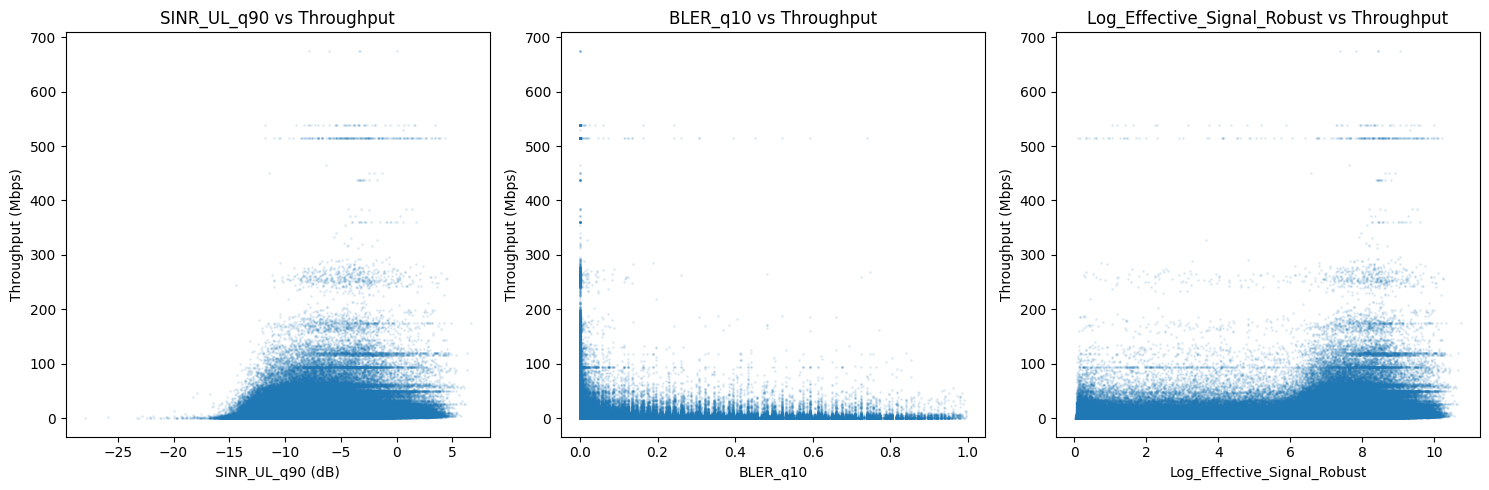

In [16]:
# ════════════════════════════════════════════════════════════════
# SECTION 2 — EDA DIAGNOSTICS (visual only, feeds no decision)
# ════════════════════════════════════════════════════════════════
active_df = arena_featured_df[arena_featured_df['Throughput'] > 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(active_df['SINR_UL_q90'], active_df['Throughput'], alpha=0.1, s=1)
axes[0].set_xlabel('SINR_UL_q90 (dB)'); axes[0].set_ylabel('Throughput (Mbps)')
axes[0].set_title('SINR_UL_q90 vs Throughput')

axes[1].scatter(active_df['BLER_q10'], active_df['Throughput'], alpha=0.1, s=1)
axes[1].set_xlabel('BLER_q10'); axes[1].set_ylabel('Throughput (Mbps)')
axes[1].set_title('BLER_q10 vs Throughput')

axes[2].scatter(active_df['Log_Effective_Signal_Robust'], active_df['Throughput'], alpha=0.1, s=1)
axes[2].set_xlabel('Log_Effective_Signal_Robust'); axes[2].set_ylabel('Throughput (Mbps)')
axes[2].set_title('Log_Effective_Signal_Robust vs Throughput')

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# Hard physical sanity filters
# ============================================================
before = len(arena_featured_df)

arena_featured_df = arena_featured_df[
    (arena_featured_df['Throughput'] >= 0) &
    (arena_featured_df['BLER'].between(0, 1)) &
    (arena_featured_df['BLER_q10'].between(0, 1)) &
    (arena_featured_df['SINR_UL'].between(-40, 30)) &
    (arena_featured_df['SINR_UL_q90'].between(-40, 30))
].copy()

after = len(arena_featured_df)
print(f"Removed {before - after:,} physically invalid rows")

spike = arena_featured_df[arena_featured_df['Throughput'] > 500]
print(spike['Throughput'].value_counts().head(20))

display(
    spike.groupby(['RU'])['Throughput']
         .agg(['count', 'mean', 'min', 'max'])
         .sort_values('count', ascending=False)
         .head(20)
)

Removed 0 physically invalid rows
Throughput
515.056030    124
514.104004     66
539.070374     26
538.849609     12
513.935974      5
538.118408      4
673.900818      4
537.897583      2
529.910400      1
675.151978      1
Name: count, dtype: int64


,count,mean,min,max
RU,,,,
10,56,520.356079,514.104004,539.070374
1,38,518.272217,513.935974,539.070374
8,31,520.857971,513.935974,539.070374
13,22,518.017761,514.104004,539.070374
14,21,539.144287,514.104004,675.151978
4,17,534.919312,514.104004,673.900818
20,13,516.537109,514.104004,539.070374
17,11,518.954163,513.935974,539.070374
16,10,530.654907,514.104004,673.900818


In [18]:
high_tp = active_df['Throughput'] >= active_df['Throughput'].quantile(0.99)
low_tp = active_df['Throughput'] <= active_df['Throughput'].quantile(0.10)

high_signal = active_df['Log_Effective_Signal_Robust'] >= active_df['Log_Effective_Signal_Robust'].quantile(0.90)
low_signal  = active_df['Log_Effective_Signal_Robust'] <= active_df['Log_Effective_Signal_Robust'].quantile(0.10)

active_df['Anomaly_Type'] = 'normal'
active_df.loc[high_tp & low_signal, 'Anomaly_Type'] = 'high_tp_bad_signal'
active_df.loc[low_tp & high_signal, 'Anomaly_Type'] = 'low_tp_good_signal'

In [19]:
# ============================================================
# Feature definition: non-leaky, non-redundant
# ============================================================
target = 'Throughput'

crowd_density = ['Crowd_Density_2m','Crowd_Density_5m','Crowd_Density_10m']

state_cols = [c for c in arena_featured_df.columns if c.startswith('State_')]

base_feats = [
    'X_meters', 'Y_meters',
    'SINR_UL','SINR_UL_q90', 'BLER','BLER_q10', 
    'RU_Current_Load', 'Velocity', 'Log_Effective_Signal_Robust'
] + [crowd_density[1]] + state_cols

# Keep only columns that actually exist
base_feats = [c for c in base_feats if c in arena_featured_df.columns]

# Safety check: drop globally constant / near-constant features
def remove_constant_features(df, cols, threshold=1e-6):
    kept, dropped = [], []
    for c in cols:
        if c in df.columns and df[c].std(skipna=True) > threshold:
            kept.append(c)
        else:
            dropped.append(c)
    if dropped:
        print("Dropped near-constant features:", dropped)
    return kept

base_feats = remove_constant_features(arena_featured_df, base_feats)

In [20]:
arena_featured_df.drop(columns=['Effective_Signal_Robust'], inplace=True) 
if not (arena_featured_df['Velocity'].notna().mean() > 0.95 and arena_featured_df['Velocity'].nunique() > 1):
    print("Velocity not added to features (constant or mostly NaN).")
    arena_featured_df.drop(columns=['Velocity'], inplace=True)

In [21]:
# manual separation dynamics and static, should be based on global activity dynamic
dynamic_cols = [
    'SINR_UL',
    'BLER',
    'SINR_UL_q90',
    'BLER_q10',
    'Log_Effective_Signal_Robust',
    'RU_Current_Load',
    'X_meters',
    'Y_meters',
    'Velocity',
] + [crowd_density[1]]

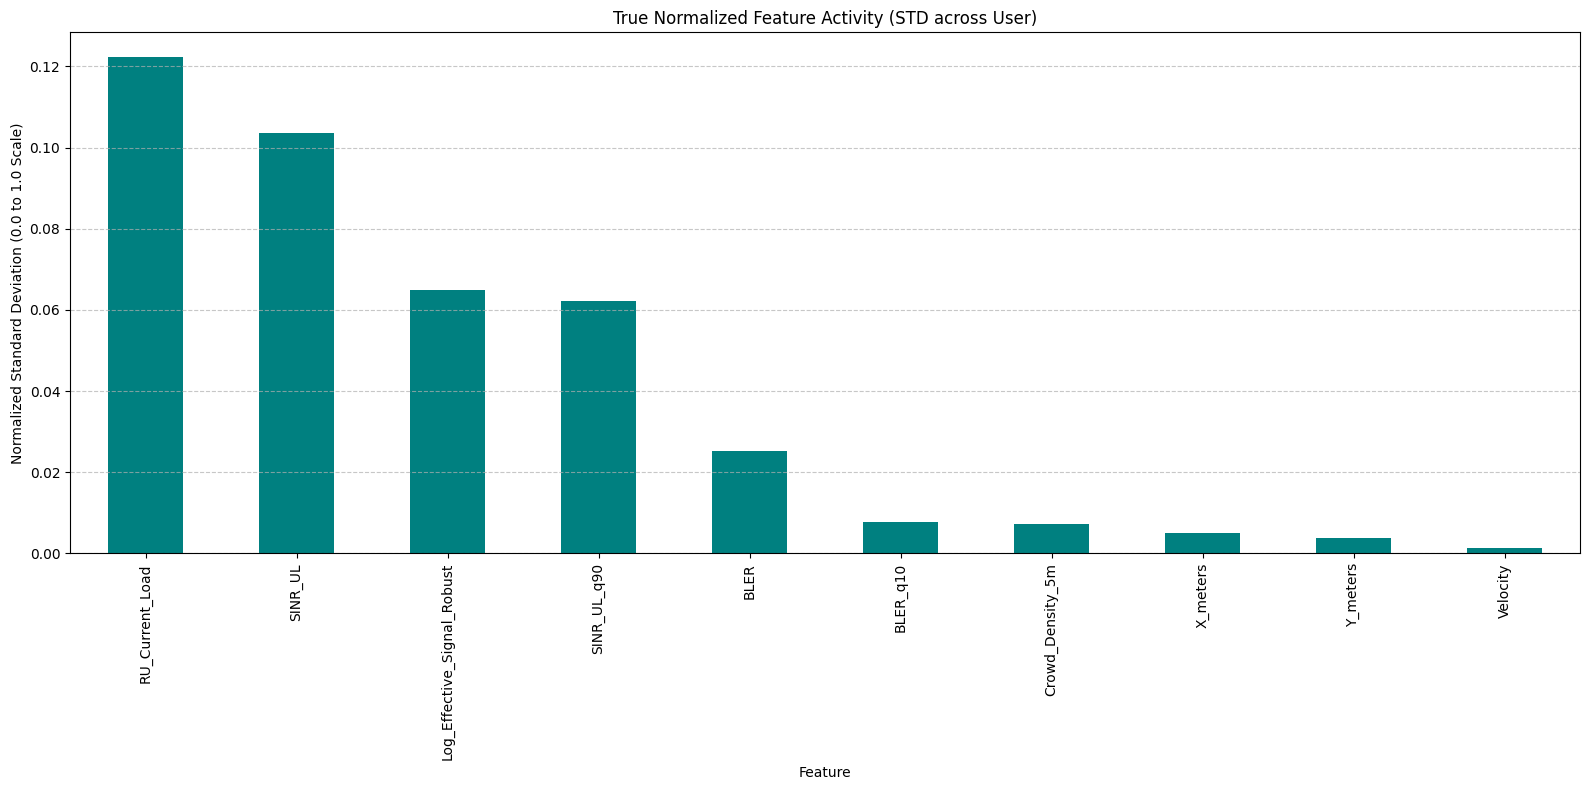

In [22]:
# Step 1: Create a temporary dataframe scaled between 0 and 1 for fair comparison
df_scaled = arena_featured_df[dynamic_cols].copy()
for col in dynamic_cols:
    col_min = df_scaled[col].min()
    col_max = df_scaled[col].max()
    if col_max - col_min > 0:
        df_scaled[col] = (df_scaled[col] - col_min) / (col_max - col_min)

# Step 2: Compute average activity on the normalized scale
# Using the User_ID from the original master dataframe to group
activity = (
    df_scaled.groupby(arena_featured_df["User_ID"])
    .std()      # Variance relative to each feature's own min/max limits
    .mean()     # Average across all 500 users
    .sort_values(ascending=False)
)

# # Step 3: Render the corrected true activity distribution
plt.figure(figsize=(16, 8))
activity.plot(kind='bar', title='True Normalized Feature Activity (STD across User)', color='teal', rot=90)
plt.xlabel('Feature')
plt.ylabel('Normalized Standard Deviation (0.0 to 1.0 Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [23]:
dyn_threshold = 1e-4
# corr = arena_featured_df[dynamic_cols].corr().abs()
# upper = corr.where(np.triu(np.ones_like(corr), 1).astype(bool))
# drop_corr = [col for col in upper.columns if any(upper[col] > 0.9)]
# dynamic_cols = [c for c in dynamic_cols if c in base_feats and activity[c] > dyn_threshold]
dynamic_cols = [c for c in dynamic_cols if c in base_feats and activity[c] > dyn_threshold]

static_cols = [c for c in state_cols if c in base_feats]

print("BASE_FEATS:", base_feats)
print("dynamic_cols:", dynamic_cols)
print("static_cols:", static_cols)

BASE_FEATS: ['X_meters', 'Y_meters', 'SINR_UL', 'SINR_UL_q90', 'BLER', 'BLER_q10', 'RU_Current_Load', 'Velocity', 'Log_Effective_Signal_Robust', 'Crowd_Density_5m', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']
dynamic_cols: ['SINR_UL', 'BLER', 'SINR_UL_q90', 'BLER_q10', 'Log_Effective_Signal_Robust', 'RU_Current_Load', 'X_meters', 'Y_meters', 'Velocity', 'Crowd_Density_5m']
static_cols: ['State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']


In [24]:
def partition_arena_vfl_channels(df):
    """
    Partitions the verified 28-column ACC Arena Master DataFrame into
    orthogonal feature spaces to satisfy strict VFL privacy constraints.
    """
    print("Executing production-grade VFL Feature Allotment...")
    
    # 1. Target Vector (Aggregator Custody)
    y_target = df['Throughput'].copy()
    
    # 2. Network Client Feature Space (Client 1) - 7 Columns
    network_cols = [
        'SINR_UL', 'PRB', 'BLER', 'RU', 
        'SINR_Linear', 'Effective_Signal', 'RU_Current_Load'
    ]
    X1_network = df[network_cols].copy()
    
    # 3. User Device Client Feature Space (Client 2) - 17 Columns
    device_cols = [
        'Latitude', 'Longitude', 'Altitude', 'X_meters', 'Y_meters', 
        'Velocity', 'Crowd_Density_2m', 'Crowd_Density_5m', 'Crowd_Density_10m',
        'MobileState', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5',
        'Resource_Efficiency'
    ]
    X2_device = df[device_cols].copy()
    
    # --- FIREWALL COMPLIANCE AUDIT ---
    print("\n[ Network Firewall Compliance Report: ]")
    print(f"Aggregator Target Shape : (y_target.shape) -> ['Throughput']")
    print(f"Client 1 Matrix Shape   : {X1_network.shape} (Network Telemetry)")
    print(f"Client 2 Matrix Shape   : {X2_device.shape} (User Domain Context)")
    
    # Mathematical Orthogonality Verification
    overlapping_features = set(X1_network.columns).intersection(set(X2_device.columns))
    assert len(overlapping_features) == 0, f"CRITICAL LEAKAGE DETECTED: {overlapping_features}"
    print("Zero Feature Leakage Confirmed! Client spaces are perfectly orthogonal.")
    
    # Total Column Audit (4 Aggregator/Meta + 7 Network + 17 Device = 28 Columns)
    total_accounted = len(network_cols) + len(device_cols) + 4
    print(f"Schema Audit Complete: {total_accounted}/28 columns successfully allocated.")
    
    return X1_network, X2_device, y_target

In mobile network traffic datasets, the dominant "Idle" state (State 1) drastically outnumbers active application sessions, creating a severe class imbalance. Training a machine learning model on this raw distribution causes it to develop a majority-class bias, where it defaults to predicting "Idle" to achieve artificial high accuracy while failing completely on active traffic. To eliminate this issue, random undersampling isolates the majority "Idle" class and downsamples its volume to perfectly match the collective sum of all active application states combined. By executing this adjustment on the master training dataset before partitioning, a perfect 50/50 balance is achieved while seamlessly maintaining aligned row indices across the orthogonal feature spaces required for Vertical Federated Learning.

Inside the training partition, the active traffic states were isolated from the dominant idle state. The majority idle class was randomly downsampled to match the exact mathematical summation of all active application instances combined:

$$\text{Total Active Samples} = 36,564 (\text{State 0}) + 3,326,584 (\text{State 2}) + 189,206 (\text{State 3}) + 133,226 (\text{State 4}) + 2,601,963 (\text{State 5}) = \mathbf{6,287,543}$$

By sampling exactly **6,287,543 records** from the idle pool, the final training dataset achieves a flawless, uniform **50/50 equilibrium** spanning a massive **12,575,086 rows**:

In [28]:
use_lag = False

In [29]:
# ────────────────────────────────────────────────────────────────
# CLEAN FEATURE DEFINITIONS
# ────────────────────────────────────────────────────────────────
df = arena_featured_df.copy()
lagged_feat = activity.head(4).index.tolist()
newly_generated_lag_cols = []

if use_lag:
  LAGS = [5, 10]
  user_ids = df['User_ID'].values
  print("generating new lagged features...")
  # Generate lagged features and update TRAIN_FEATS with their names
  # for col in train_feats_base:
  for col in lagged_feat:
      arr = df[col]
      for lag in LAGS:
        new_col = f'{col}_lag{lag}'
        shifted = np.full(len(df), np.nan, dtype=np.float32)
        shifted[lag:] = arr[:-lag]
        invalid = np.zeros(len(df), dtype=bool)
        invalid[lag:] = (user_ids[lag:] != user_ids[:-lag])
        shifted[invalid] = np.nan
        df[new_col] = shifted
        newly_generated_lag_cols.append(new_col)
    
    # Quick check: manual shift just to check correlation with your target variable
  for col in newly_generated_lag_cols:
    corr = df[col].corr(df[target])
    print(f"{col} Lag Corr with Target: {corr:.4f}")

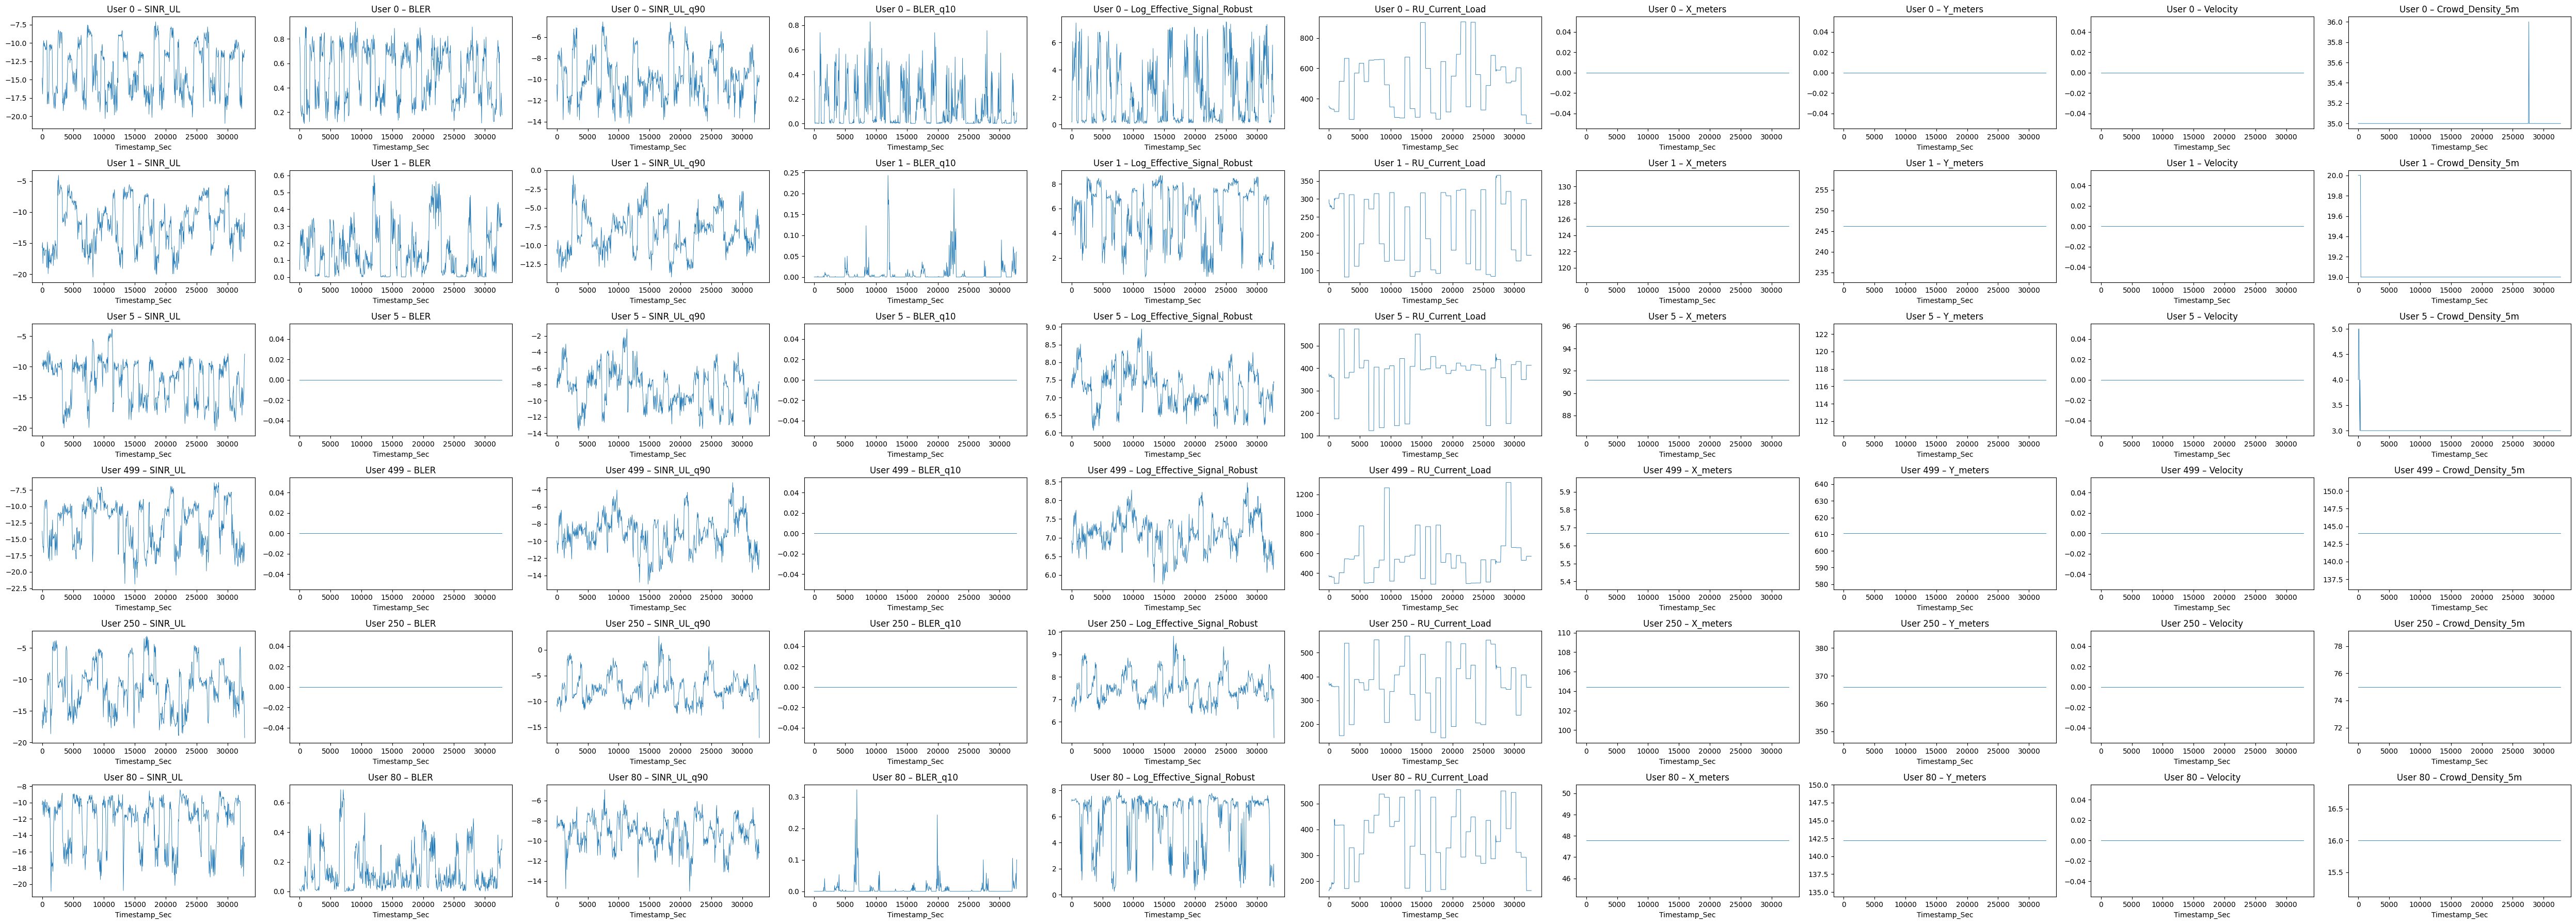

In [31]:
sample_users = [0, 1, 5, 499, 250, 80]  # pick any three existing User_IDs

features_to_plot = dynamic_cols

fig, axes = plt.subplots(len(sample_users), len(features_to_plot),
                         figsize=(5*len(features_to_plot), 3*len(sample_users)))
for i, uid in enumerate(sample_users):
    u = df[df['User_ID'] == uid].sort_values('Timestamp_Sec')
    for j, feat in enumerate(features_to_plot):
        ax = axes[i, j] if len(sample_users)>1 else axes[j]
        ax.plot(u['Timestamp_Sec'], u[feat], linewidth=0.6)
        ax.set_title(f'User {uid} – {feat}')
        ax.set_xlabel('Timestamp_Sec')
plt.tight_layout()
plt.show()

In [30]:
df['Has_Throughput'] = (df[target] > 0).astype(np.int8)
active_ratio = df['Has_Throughput'].mean()
print(f"Active (throughput > 0): {active_ratio*100:.1f}%  |  Idle: {(1-active_ratio)*100:.1f}%")

Active (throughput > 0): 29.9%  |  Idle: 70.1%


In [ ]:
def train_test_split(df, test_id_start=10000, val_frac=0.20, random_seed=42, is_undersampling=False):
    if (max_user_id == 1499):
        test_id_start = 1200
    # 1. Split out test set (last 800 users)
    test_df = df[df['User_ID'] >= test_id_start].copy()
    train_val_df = df[df['User_ID'] < test_id_start].copy()
    
    # 2. Get unique users from train_val and shuffle
    unique_users = train_val_df['User_ID'].unique().tolist()
    random.seed(random_seed)
    random.shuffle(unique_users)
    
    val_size = int(len(unique_users) * val_frac)
    val_users = set(unique_users[:val_size])
    train_users = set(unique_users[val_size:])

    # 3. Create training and validation DataFrames
    train_df = train_val_df[train_val_df['User_ID'].isin(train_users)].copy()
    val_df = train_val_df[train_val_df['User_ID'].isin(val_users)].copy()

    if is_undersampling:
        print("2. Undersampling the Training Data...")
        # Separate the classes INSIDE the training set only
        idle_rows = train_df[train_df['Has_Throughput'] == 0]
        active_rows = train_df[train_df['Has_Throughput'] != 0]
        
        # Undersample the Idle class to perfectly match the active traffic volume (1:1 balance)
        sampled_idle = idle_rows.sample(n=len(active_rows), random_state=random_seed)
        
        # Combine and Shuffle to create the final balanced training set
        train_df = pd.concat([active_rows, sampled_idle], axis=0).sample(frac=1, random_state=random_seed).reset_index(drop=True)
        print(f"✅ New Balanced Training Shape: {train_df.shape}")
        print(f"✅ Untouched Validation Shape: {val_df.shape}")

    print(f"  Test users:   {len(test_df['User_ID'].unique())} → {len(test_df):,} rows")
    print(f"  Train users:  {len(train_users)} → {len(train_df):,} rows")
    print(f"  Val users:    {len(val_users)}   → {len(val_df):,} rows")
    return train_df, val_df, test_df

In [33]:
print("\n=== TRAIN, VAL/ TEST SPLIT ===")
# don't undersample for training the LSTM + MLP static
train_df, val_df, test_df = train_test_split(df, is_undersampling=False)


=== TRAIN, VAL/ TEST SPLIT ===
  Test users:   2000 → 1,094,000 rows
  Train users:  8000 → 4,376,000 rows
  Val users:    2000   → 1,094,000 rows


In [34]:
# after undersampling: count rows per user
full_counts = train_df.groupby('User_ID').size()
print(full_counts.describe())
print(f"Unique timestep counts: {full_counts.nunique()}")

count    8000.0
mean      547.0
std         0.0
min       547.0
25%       547.0
50%       547.0
75%       547.0
max       547.0
dtype: float64
Unique timestep counts: 1


In [35]:
# Compute fill values from training set ONLY
fill_vals = train_df.mean(numeric_only=True)

train_df.fillna(fill_vals, inplace=True)
val_df.fillna(fill_vals, inplace=True)
test_df.fillna(fill_vals, inplace=True)

# 3. Fill Lag NaNs with a Sentinel Value (-999) to indicate "Session Just Started"
# train_df[lag_cols] = train_df[lag_cols].fillna(-999)
# val_df[lag_cols] = val_df[lag_cols].fillna(-999)
# test_df[lag_cols] = test_df[lag_cols].fillna(-999)

In [36]:
train_pos = train_df[train_df['Has_Throughput'] == 1].copy()
val_pos = val_df[val_df['Has_Throughput'] == 1].copy()
test_pos  = test_df[test_df['Has_Throughput']  == 1].copy()
print(f"Train active rows: {len(train_pos):,}| Val active rows: {len(val_pos):,} | Test active rows: {len(test_pos):,}")

Train active rows: 1,392,756| Val active rows: 377,766 | Test active rows: 188,845


In [37]:
# ── Logging config — toggle these freely ──
LOG_CV_VERBOSE    = 3     # 0=silent, 1=time only, 2=score per fold, 3=fold+size
LOG_EPOCH_VERBOSE = True  # DNN epoch-by-epoch loss (final fit only, not during CV)
LOG_RF_TREES      = 1     # RF tree-building progress (0=silent, 1=parallel progress)
RANDOM_STATE = 42
ACTIVE_THRESHOLD = 0.5
SAMPLE_N_S1 = 800_000
SAMPLE_N_S2 = 500_000
N_ESTIMATOR = 100
MAX_DEPTH = 20

In [ ]:
# Ensure directory for saving models exists
os.makedirs(working + "saved_models", exist_ok=True)

def sample_xy(X, y, sample_n=None, random_state=42):
    """sample_n=None (or >= len(X)) => use ALL rows, no subsampling."""
    if sample_n is None or len(X) <= sample_n:
        return X, y
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(X), size=sample_n, replace=False)
    return X[idx], y[idx]


def train_stage1_random_forest_classifier(X_train, y_train, sample_n=None, random_state=RANDOM_STATE):
    start = time.time()
    X_fit, y_fit = sample_xy(X_train, y_train, sample_n=sample_n, random_state=random_state)

    mode = "FULL dataset" if (sample_n is None or sample_n >= len(X_train)) else f"sample of {sample_n:,}"
    print(f"Stage 1 RF training on {mode} ({len(X_fit):,} / {len(X_train):,} rows)")

    if USE_GPU_RF:
        # NOTE: cuML's RandomForestClassifier does not support class_weight.
        model = cuRFClassifier(n_estimators=N_ESTIMATOR, max_depth=MAX_DEPTH, random_state=random_state, n_streams=8)
        X_fit_gpu = cp.asarray(X_fit.astype(np.float32))
        y_fit_gpu = cp.asarray(y_fit.astype(np.int32))
        model.fit(X_fit_gpu, y_fit_gpu)
        backend = "gpu_cuml"

        # Explicitly free up GPU arrays right after fitting
        del X_fit_gpu, y_fit_gpu
        cp.get_default_memory_pool().free_all_blocks()
    else:
        model = RandomForestClassifier(
            n_estimators=N_ESTIMATOR, max_depth=MAX_DEPTH, n_jobs=-1,
            random_state=random_state, verbose=LOG_RF_TREES,
            class_weight='balanced',   # handles the 50/63% idle/active imbalance
        )
        model.fit(X_fit, y_fit)
        backend = "cpu_sklearn"
    # Clean up intermediate fit arrays
    del X_fit, y_fit
    gc.collect()
    
    return model, backend, time.time() - start

def train_stage2_random_forest_regressor(X_train, y_train, sample_n=None, random_state=RANDOM_STATE, n_estimator=100, max_depth=20, max_features='sqrt'):
    start = time.time()
    X_fit, y_fit = sample_xy(X_train, y_train, sample_n=sample_n, random_state=random_state)

    mode = "FULL dataset" if (sample_n is None or sample_n >= len(X_train)) else f"sample of {sample_n:,}"
    print(f"Stage 2 RF training on {mode} ({len(X_fit):,} / {len(X_train):,} active rows)")

    if USE_GPU_RF:
        model = cuRFRegressor(n_estimators=n_estimator, max_depth=max_depth, random_state=random_state, n_streams=8)
        X_fit_gpu = cp.asarray(X_fit.astype(np.float32))
        y_fit_gpu = cp.asarray(y_fit.astype(np.float32))
        model.fit(X_fit_gpu, y_fit_gpu)
        backend = "gpu_cuml"
        
        # Explicitly free up GPU arrays right after fitting
        del X_fit_gpu, y_fit_gpu
        cp.get_default_memory_pool().free_all_blocks()
    else:
        model = RandomForestRegressor(
            n_estimators=n_estimator, max_depth=max_depth, n_jobs=-1,
            random_state=random_state, verbose=LOG_RF_TREES,
        )
        model.fit(X_fit, y_fit)
        backend = "cpu_sklearn"
        # Clean up intermediate fit arrays
    del X_fit, y_fit
    gc.collect()

    return model, backend, time.time() - start

In [39]:
# ════════════════════════════════════════════════════════════════
# SECTION 9 — EVALUATION HELPERS
# ════════════════════════════════════════════════════════════════
def to_numpy_safe(x):
    try:
        if isinstance(x, cp.ndarray):
            return cp.asnumpy(x)
    except Exception:
        pass
    return x.to_numpy() if hasattr(x, "to_numpy") else np.asarray(x)


def predict_rf(model, backend, X):
    if "gpu" in backend.lower():
        X_gpu = cp.asarray(X.astype(np.float32))
        preds = to_numpy_safe(model.predict(X_gpu))
        del X_gpu
        cp.get_default_memory_pool().free_all_blocks()
        return preds
    return model.predict(X)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def eval_regression(y_true, y_pred, prefix=""):
    y_true_log = np.log1p(y_true)
    y_pred_log = np.log1p(np.clip(y_pred, 0, None))
    return {
        f"{prefix}MAE_raw": mean_absolute_error(y_true, y_pred),
        f"{prefix}RMSE_raw": rmse(y_true, y_pred),
        f"{prefix}R2_raw": r2_score(y_true, y_pred),
        f"{prefix}MAE_log": mean_absolute_error(y_true_log, y_pred_log),
        f"{prefix}RMSE_log": rmse(y_true_log, y_pred_log),
        f"{prefix}R2_log": r2_score(y_true_log, y_pred_log),
    }

def combine_stages(s1_pred, X_s1, full_len, reg_model, reg_backend):
    final_pred = np.zeros(full_len, dtype=np.float32)
    active_idx = np.where(s1_pred == 1)[0]
    if len(active_idx) > 0:
        log_pred = predict_rf(reg_model, reg_backend, X_s1[active_idx])
        final_pred[active_idx] = np.expm1(log_pred)
    return np.clip(final_pred, 0, None)
    
def existing_cols(df, cols):
    return [c for c in cols if c in df.columns]

In [83]:
# ════════════════════════════════════════════════════════════════
# SECTION 10 — FEATURE SET DEFINITIONS
# Add/edit experiments here — the loop below picks them up automatically.
# ════════════════════════════════════════════════════════════════
state_cols = [c for c in train_df.columns if c.startswith("State_")]

mean_only_cols = ['SINR_UL', 'BLER', 'X_meters', 'Y_meters', 'RU_Current_Load', 'Velocity'] + [crowd_density[1]]
peak_cols      = ['SINR_UL_q90', 'BLER_q10', 'Log_Effective_Signal_Robust']
leaky_cols     = ['PRB', 'Resource_Efficiency']

# just use 1 set if it's finalized
feature_sets = {
    # "B_mean_only_non_leaky":   existing_cols(train_df, mean_only_cols + state_cols),
    # "C_peak_enhanced_non_leaky": existing_cols(train_df, mean_only_cols + peak_cols + state_cols),
    "D_peak_lagged_non_leaky": existing_cols(train_df, mean_only_cols + peak_cols + state_cols),
}
# if any(c in train_df.columns for c in leaky_cols):
#     feature_sets["A_leaky_upper_bound"] = existing_cols(
#         train_df, mean_only_cols + peak_cols + leaky_cols + state_cols
#     )

print("Feature sets:")
for name, feats in feature_sets.items():
    print(f"\n{name}: {len(feats)} features\n{feats}")

Feature sets:

D_peak_lagged_non_leaky: 16 features
['SINR_UL', 'BLER', 'X_meters', 'Y_meters', 'RU_Current_Load', 'Velocity', 'Crowd_Density_5m', 'SINR_UL_q90', 'BLER_q10', 'Log_Effective_Signal_Robust', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']


In [84]:
# ════════════════════════════════════════════════════════════════
# PHASE 1 — FEATURE SEARCH LOOP (SUBSAMPLED, VALIDATION ONLY)
# ════════════════════════════════════════════════════════════════
all_results = []

print("=" * 80)
print("PHASE 1: RUNNING FEATURE SET EXPERIMENTS (SUBSAMPLED)")
print("=" * 80)

for exp_name, train_feats in feature_sets.items():
    print(f"\nEvaluating Feature Set: {exp_name}")

    # Prepare Training Matrices (Subsampled via helper later)
    X_train_s1 = train_df[train_feats].astype(np.float32).values
    y_train_s1 = train_df["Has_Throughput"].values.astype(np.int32)
    X_train_s2 = train_pos[train_feats].astype(np.float32).values
    y_train_s2 = np.log1p(train_pos[target].values.astype(np.float32))

    # Prepare Validation Matrices
    X_val_s1   = val_df[train_feats].astype(np.float32).values
    y_val_s1   = val_df["Has_Throughput"].values.astype(np.int32)
    X_val_s2   = val_pos[train_feats].astype(np.float32).values
    y_val_s2_original = val_pos[target].values.astype(np.float32)
    y_val_full  = val_df[target].values.astype(np.float32)

    # Train (With Subsampling)
    stage1_classifier, stage1_backend, stage1_time = train_stage1_random_forest_classifier(
        X_train_s1, y_train_s1, sample_n=SAMPLE_N_S1
    )
    
    stage2_regressor, stage2_backend, stage2_time = train_stage2_random_forest_regressor(
        X_train_s2, y_train_s2, sample_n=SAMPLE_N_S2, n_estimator=N_ESTIMATOR, max_depth=MAX_DEPTH,
    )

    # Free training matrices immediately
    del X_train_s1, y_train_s1, X_train_s2, y_train_s2
    gc.collect()

    # Inference on Validation Set Only
    val_s1_pred = predict_rf(stage1_classifier, stage1_backend, X_val_s1).astype(int)
    val_s1_acc, val_s1_f1 = accuracy_score(y_val_s1, val_s1_pred), f1_score(y_val_s1, val_s1_pred)

    val_s2_pred = np.clip(np.expm1(predict_rf(stage2_regressor, stage2_backend, X_val_s2)), 0, None)
    val_s2_metrics = eval_regression(y_val_s2_original, val_s2_pred, prefix="val_stage2_")

    val_final_pred = combine_stages(val_s1_pred, X_val_s1, len(val_df), stage2_regressor, stage2_backend)
    val_final_metrics = eval_regression(y_val_full, val_final_pred, prefix="val_final_")

    # Extract Feature Importances
    s1_imps = to_numpy_safe(stage1_classifier.feature_importances_)
    s2_imps = to_numpy_safe(stage2_regressor.feature_importances_)

    row = {
        "experiment": exp_name, "n_features": len(train_feats), "features": train_feats,
        "stage1_time_sec": stage1_time, "stage2_time_sec": stage2_time,
        "val_stage1_acc": val_s1_acc, "val_stage1_f1": val_s1_f1,
        "stage1_feature_importances": dict(zip(train_feats, s1_imps)),
        "stage2_feature_importances": dict(zip(train_feats, s2_imps))
    }
    row.update(val_s2_metrics)
    row.update(val_final_metrics)
    all_results.append(row)

    # Scrub memory clean before starting next feature loop
    del (
        stage1_classifier, stage2_regressor,
        X_val_s1, y_val_s1, X_val_s2, y_val_s2_original,
        y_val_full, val_s1_pred, val_s2_pred, val_final_pred
    )
    gc.collect()
    if USE_GPU_RF:
        cp.get_default_memory_pool().free_all_blocks()

PHASE 1: RUNNING FEATURE SET EXPERIMENTS (SUBSAMPLED)

Evaluating Feature Set: D_peak_lagged_non_leaky
Stage 1 RF training on sample of 800,000 (800,000 / 4,376,000 rows)
Stage 2 RF training on sample of 500,000 (500,000 / 1,392,756 active rows)


In [85]:
# ════════════════════════════════════════════════════════════════
# SECTION 12 — DISPLAY SELECTION TABLE
# ════════════════════════════════════════════════════════════════
rf_compare_df = pd.DataFrame(all_results)
display_cols = [
    "experiment", "n_features", "val_stage1_f1", 
    "val_stage2_R2_log", "val_final_R2_log", "val_final_RMSE_raw",
    "stage1_time_sec", "stage2_time_sec"
]
rf_compare_display = (
    rf_compare_df[display_cols]
    .sort_values("val_final_R2_log", ascending=False)
    .reset_index(drop=True)
)
print("\n" + "=" * 80)
print("EXPERIMENT COMPARISON (ORDERED BY VALIDATION PERFORMANCE)")
print("=" * 80)
display(rf_compare_display)


EXPERIMENT COMPARISON (ORDERED BY VALIDATION PERFORMANCE)


,experiment,n_features,val_stage1_f1,val_stage2_R2_log,val_final_R2_log,val_final_RMSE_raw,stage1_time_sec,stage2_time_sec
0,D_peak_lagged_non_leaky,16,0.999721,0.321479,0.796677,6.514972,2.616041,16.473811


In [86]:
# ════════════════════════════════════════════════════════════════
# SECTION 13 — DISPLAY FEATURE IMPORTANCES
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("FEATURE IMPORTANCES BY EXPERIMENT")
print("=" * 80)

for _, row in rf_compare_df.iterrows():
    print(f"\n🚀 Experiment: {row['experiment']}")
    
    # Combine the two dictionaries into a single side-by-side DataFrame
    imps_df = pd.DataFrame({
        "Stage 1": row["stage1_feature_importances"],
        "Stage 2": row["stage2_feature_importances"]
    }).fillna(0).sort_values(by="Stage 2", ascending=False)
    
    display(imps_df)


FEATURE IMPORTANCES BY EXPERIMENT

🚀 Experiment: D_peak_lagged_non_leaky


,Stage 1,Stage 2
RU_Current_Load,0.000132,0.300158
BLER,0.361932,0.265966
Log_Effective_Signal_Robust,0.012077,0.101802
SINR_UL,0.000117,0.092409
X_meters,0.000336,0.047964
SINR_UL_q90,0.000120,0.047302
Crowd_Density_5m,0.001103,0.045972
Y_meters,0.000119,0.040779
BLER_q10,0.341149,0.026512
State_5,0.024959,0.017167


In [100]:
dir_name = "saved_models"

# 2. This works because you are ALREADY inside /kaggle/working
os.makedirs(dir_name, exist_ok=True)

# 3. Double check it exists
if os.path.exists(dir_name):
    print(f"Success: {dir_name} is ready for saving.")
else:
    print(f"Error: {dir_name} was not created. Check your permissions.")

Success: saved_models is ready for saving.


In [101]:
# ════════════════════════════════════════════════════════════════
# PHASE 2 — RETRAIN WINNER ON FULL DATASET & EVALUATE ON TEST
# ════════════════════════════════════════════════════════════════
# is_clean = rf_compare_display['experiment'].apply(
#     lambda exp: not any(f in leaky_cols for f in next(item["features"] for item in all_results if item["experiment"] == exp))
# )

# 3. Select the best clean model
# best_exp_name = rf_compare_display[is_clean].sort_values("val_final_R2_log", ascending=False).iloc[0]['experiment']
best_exp_name = "D_peak_lagged_non_leaky"

# Find original features list for the winner
# best_feats = next(item["features"] for item in all_results if item["experiment"] == best_exp_name)
best_feats = feature_sets["D_peak_lagged_non_leaky"]

print("\n" + "═" * 80)
# print(f"WINNER CHOSEN: {best_exp_name}")
print(f"RETRAINING ON FULL DATASET (sample_n = None) FOR FINAL TEST EVALUATION")
print("═" * 80)

# 1. Pull FULL arrays for winner
X_train_full_s1 = train_df[best_feats].astype(np.float32).values
y_train_full_s1 = train_df["Has_Throughput"].values.astype(np.int32)
X_train_full_s2 = train_pos[best_feats].astype(np.float32).values
y_train_full_s2 = np.log1p(train_pos[target].values.astype(np.float32))

# 2. Train on full data (sample_n=None)
final_stage1_model, stage1_backend, _ = train_stage1_random_forest_classifier(
    X_train_full_s1, y_train_full_s1, sample_n=None
)

# Save best final models to disk
joblib.dump(final_stage1_model, f"{dir_name}/{best_exp_name}_FULL_stage1_clf.joblib")
# joblib.dump(final_stage1_model, f"{dir_name}/FULL_stage1_clf.joblib")

# del X_train_full_s1, y_train_full_s1, all_results, rf_compare_df, rf_compare_display
del X_train_full_s1, y_train_full_s1
gc.collect()


════════════════════════════════════════════════════════════════════════════════
RETRAINING ON FULL DATASET (sample_n = None) FOR FINAL TEST EVALUATION
════════════════════════════════════════════════════════════════════════════════
Stage 1 RF training on FULL dataset (4,376,000 / 4,376,000 rows)


NameError: name 'all_results' is not defined

In [104]:
final_stage2_model, stage2_backend, _ = train_stage2_random_forest_regressor(
    X_train_full_s2, y_train_full_s2, sample_n=None, n_estimator=N_ESTIMATOR, max_depth=MAX_DEPTH,
)
    
joblib.dump(final_stage2_model, f"{dir_name}/{best_exp_name}_FULL_stage2_reg.joblib")

# Free training arrays
del X_train_full_s2, y_train_full_s2
gc.collect()

Stage 2 RF training on FULL dataset (1,392,756 / 1,392,756 active rows)


0

In [105]:
# 4. Prepare Validation Matrices for Feature Set
X_val_s1   = val_df[best_feats].astype(np.float32).values
y_val_s1   = val_df["Has_Throughput"].values.astype(np.int32)
X_val_s2   = val_pos[best_feats].astype(np.float32).values
y_val_s2_original = val_pos[target].values.astype(np.float32)
y_val_full  = val_df[target].values.astype(np.float32)

# 5. Run Validation Inference
print("🔮 Running inference on Validation Set with full-trained models...")
val_s1_pred = predict_rf(final_stage1_model, stage1_backend, X_val_s1).astype(int)
val_s2_pred = np.clip(np.expm1(predict_rf(final_stage2_model, stage2_backend, X_val_s2)), 0, None)
val_final_pred = combine_stages(val_s1_pred, X_val_s1, len(val_df), final_stage2_model, stage2_backend)

# 6. Compute and Print Validation Metrics
val_s1_acc = accuracy_score(y_val_s1, val_s1_pred)
val_s1_f1  = f1_score(y_val_s1, val_s1_pred)
val_s2_metrics = eval_regression(y_val_s2_original, val_s2_pred, prefix="val_stage2_")
val_final_metrics = eval_regression(y_val_full, val_final_pred, prefix="val_final_")

🔮 Running inference on Validation Set with full-trained models...


In [106]:
print("\n" + "=" * 50)
print("   FULL DATASET RANDOM FOREST VALIDATION METRICS")
print("=" * 50)
print(f"Stage 1 Classifier Accuracy : {val_s1_acc:.4f}")
print(f"Stage 1 Classifier F1-Score : {val_s1_f1:.4f}")

print(f"Stage 2 Regressor R2 (Log)  : {val_s2_metrics['val_stage2_R2_log']:.4f}")
print(f"Stage 2 Regressor MAE (Log) : {val_s2_metrics['val_stage2_MAE_log']:.4f}")
print(f"Stage 2 Regressor RMSE (Log): {val_s2_metrics['val_stage2_RMSE_log']:.4f}")
print(f"Stage 2 Regressor R2        : {val_s2_metrics['val_stage2_R2_raw']:.4f}")
print(f"Stage 2 Regressor MAE       : {val_s2_metrics['val_stage2_MAE_raw']:.4f} Mbps")
print(f"Stage 2 Regressor RMSE      : {val_s2_metrics['val_stage2_RMSE_raw']:.4f} Mbps")

print(f"Final Combined R2 (Log)     : {val_final_metrics['val_final_R2_log']:.4f}")
print(f"Final Combined MAE (Log)    : {val_final_metrics['val_final_MAE_log']:.4f}")
print(f"Final Combined RMSE (Log)   : {val_final_metrics['val_final_RMSE_log']:.2f}")
print(f"Final Combined R2           : {val_final_metrics['val_final_R2_raw']:.4f}")
print(f"Final Combined MAE          : {val_final_metrics['val_final_MAE_raw']:.4f} Mbps")
print(f"Final Combined RMSE         : {val_final_metrics['val_final_RMSE_raw']:.2f} Mbps")
print("=" * 50)

# 7. Complete Memory Scrub - Flush models out before Neural Net Phase
print("\n🧼 Scrubbing memory clean for next phases...")
del (
    final_stage1_model, final_stage2_model,
    X_val_s1,  X_val_s2,
    val_s1_pred, val_s2_pred
)

gc.collect()

if USE_GPU_RF:
    cp.get_default_memory_pool().free_all_blocks()
    
print("✅ Memory clear. Ready for Deep Learning section.")


   FULL DATASET RANDOM FOREST VALIDATION METRICS
Stage 1 Classifier Accuracy : 0.9998
Stage 1 Classifier F1-Score : 0.9997
Stage 2 Regressor R2 (Log)  : 0.3265
Stage 2 Regressor MAE (Log) : 0.4739
Stage 2 Regressor RMSE (Log): 0.6224
Stage 2 Regressor R2        : 0.1311
Stage 2 Regressor MAE       : 3.5138 Mbps
Stage 2 Regressor RMSE      : 11.0614 Mbps
Final Combined R2 (Log)     : 0.7982
Final Combined MAE (Log)    : 0.1639
Final Combined RMSE (Log)   : 0.37
Final Combined R2           : 0.2336
Final Combined MAE          : 1.2138 Mbps
Final Combined RMSE         : 6.50 Mbps

🧼 Scrubbing memory clean for next phases...
✅ Memory clear. Ready for Deep Learning section.


In [107]:
# ═══════════════════════════════════════════════════════════════
# VFL EXPERIMENTS WITH RANDOM FOREST (TWO‑STAGE)
# ═══════════════════════════════════════════════════════════════

# --- feature split (same as you specified) ---
ue_features = [
    "X_meters", "Y_meters", "Velocity",
] + state_cols

ru_features = [
    "SINR_UL", "BLER", "RU_Current_Load",
    "Log_Effective_Signal_Robust", "SINR_UL_q90", "BLER_q10"
] + [crowd_density[1]]


# Keep only columns that actually exist
print("UE features:", ue_features)
print("RU features:", ru_features)
print("PREVIOUS features:", best_feats)
assert set(best_feats) == set(ue_features + ru_features)
assert len(set(ue_features).intersection(set(ru_features))) == 0
assert(len(best_feats) == len(ue_features)+len(ru_features))

UE features: ['X_meters', 'Y_meters', 'Velocity', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']
RU features: ['SINR_UL', 'BLER', 'RU_Current_Load', 'Log_Effective_Signal_Robust', 'SINR_UL_q90', 'BLER_q10', 'Crowd_Density_5m']
PREVIOUS features: ['SINR_UL', 'BLER', 'X_meters', 'Y_meters', 'RU_Current_Load', 'Velocity', 'Crowd_Density_5m', 'SINR_UL_q90', 'BLER_q10', 'Log_Effective_Signal_Robust', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']


In [ ]:
train_users = train_df["User_ID"].unique()
rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(train_users)
split_idx = int(len(train_users) * 0.8)
base_users = train_users[:split_idx]
meta_users = train_users[split_idx:]

train_base_df = train_df[train_df["User_ID"].isin(base_users)]
train_meta_df = train_df[train_df["User_ID"].isin(meta_users)]
# Active‑only for regressor training
train_base_pos = train_base_df[train_base_df["Has_Throughput"] == 1]
train_meta_pos = train_meta_df[train_meta_df["Has_Throughput"] == 1]

print(f"Base training users: {len(base_users):,} | Meta training users: {len(meta_users):,}")

In [ ]:
# --- Prepare data for each party ---
def prepare_party_data(feats):
    X_train_s1 = train_base_df[feats].astype(np.float32).values
    y_train_s1 = train_base_df["Has_Throughput"].values.astype(np.int32)
    X_train_s2 = train_base_pos[feats].astype(np.float32).values
    y_train_s2 = np.log1p(train_base_pos[target].values.astype(np.float32))

    X_meta_s1 = train_meta_df[feats].astype(np.float32).values
    y_meta_s1 = train_meta_df["Has_Throughput"].values.astype(np.int32)

    X_meta_s2 = train_meta_pos[feats].astype(np.float32).values
    y_meta_s2 = np.log1p(train_meta_pos[target].values.astype(np.float32))

    X_val_s1 = val_df[feats].astype(np.float32).values
    y_val_s1 = val_df["Has_Throughput"].values.astype(np.int32)
    X_val_s2 = val_pos[feats].astype(np.float32).values
    y_val_s2_orig = val_pos[target].values.astype(np.float32)
    y_val_full = val_df[target].values.astype(np.float32)

    X_test_s1 = test_df[feats].astype(np.float32).values
    y_test_s1 = test_df["Has_Throughput"].values.astype(np.int32)
    X_test_s2 = test_pos[feats].astype(np.float32).values
    y_test_s2_orig = test_pos[target].values.astype(np.float32)
    y_test_full = test_df[target].values.astype(np.float32)

    return (X_train_s1, y_train_s1, X_train_s2, y_train_s2,
            X_meta_s1, y_meta_s1, X_meta_s2, y_meta_s2,
            X_val_s1, y_val_s1, X_val_s2, y_val_s2_orig, y_val_full,
            X_test_s1, y_test_s1, X_test_s2, y_test_s2_orig, y_test_full)

# UE party
(ue_tr_s1, ue_tr_y1, ue_tr_s2, ue_tr_y2,
 ue_tr_meta_s1, y_meta_s1, ue_tr_meta_s2, y_meta_s2,
 ue_val_s1, ue_val_y1, ue_val_s2, ue_val_y2o, ue_val_full,
 ue_te_s1, ue_te_y1, ue_te_s2, ue_te_y2o, ue_te_full) = prepare_party_data(ue_features)

# RU party
(ru_tr_s1, ru_tr_y1, ru_tr_s2, ru_tr_y2,
 ru_tr_meta_s1, _, ru_tr_meta_s2, _,
 ru_val_s1, ru_val_y1, ru_val_s2, ru_val_y2o, ru_val_full,
 ru_te_s1, ru_te_y1, ru_te_s2, ru_te_y2o, ru_te_full) = prepare_party_data(ru_features)

# --- Train single‑party models (Stage 1 & Stage 2) ---
print("\n--- Training UE‑only Random Forest (2‑stage) ---")
ue_clf, ue_clf_backend, _ = train_stage1_random_forest_classifier(ue_tr_s1, ue_tr_y1, sample_n=None)
ue_reg, ue_reg_backend, _ = train_stage2_random_forest_regressor(ue_tr_s2, ue_tr_y2, sample_n=None)

print("\n--- Training RU‑only Random Forest (2‑stage) ---")
ru_clf, ru_clf_backend, _ = train_stage1_random_forest_classifier(ru_tr_s1, ru_tr_y1, sample_n=None)
ru_reg, ru_reg_backend, _ = train_stage2_random_forest_regressor(ru_tr_s2, ru_tr_y2, sample_n=None)


--- Training UE‑only Random Forest (2‑stage) ---
Stage 1 RF training on FULL dataset (4,376,000 / 4,376,000 rows)
Stage 2 RF training on FULL dataset (1,392,756 / 1,392,756 active rows)

--- Training RU‑only Random Forest (2‑stage) ---
Stage 1 RF training on FULL dataset (4,376,000 / 4,376,000 rows)
Stage 2 RF training on FULL dataset (1,392,756 / 1,392,756 active rows)


In [ ]:


print("\n" + "═" * 70)
print(" 🚀 STAGE 1: THE RUBRIC-STRICT COMBINED LINEAR VFL BASELINE")
print("═" * 70)

# In a simulated academic environment, training a linear model on 
# the concatenated features perfectly represents the mathematical 
# outcome of a linearly federated gradient-descent model.
combined_vfl_features = ue_features + ru_features

# Ensure we haven't leaked any overlap between parties
assert set(best_feats) == set(combined_vfl_features), "Feature mismatch!"
assert len(set(ue_features).intersection(ru_features)) == 0, "Feature overlap detected!"

# --- 1. Train the Linear VFL Classifier (Active vs Idle) ---
linear_vfl_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
)
linear_vfl_clf.fit(train_df[combined_vfl_features], train_df["Has_Throughput"])

# --- 2. Train the Linear VFL Regressor (Log-Throughput) ---
linear_vfl_reg = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0, solver="lsqr", random_state=RANDOM_STATE)
)
# Train only on active (positive throughput) rows
linear_vfl_reg.fit(train_pos[combined_vfl_features], np.log1p(train_pos[target]))

# --- 3. Predict & Evaluate on Validation Set ---
lin_val_s1_pred = linear_vfl_clf.predict(val_df[combined_vfl_features])
lin_val_s2_log_pred = linear_vfl_reg.predict(val_df[combined_vfl_features])

# Combine predictions
lin_val_final_pred = np.where(lin_val_s1_pred == 1, np.expm1(lin_val_s2_log_pred), 0.0)
lin_val_final_pred = np.clip(lin_val_final_pred, 0, None)

# Get metrics
linear_vfl_metrics = eval_regression(val_df[target].values, lin_val_final_pred, prefix="lin_vfl_")
print("✅ Basic Linear VFL Baseline Complete.")
print(linear_vfl_metrics)

In [109]:
def get_proba(model, backend, X):
    if "gpu" in backend.lower():
        X_gpu = cp.asarray(X.astype(np.float32))
        proba = to_numpy_safe(model.predict_proba(X_gpu))[:,1]
        del X_gpu
        cp.get_default_memory_pool().free_all_blocks()
        return proba
    else:
        return model.predict_proba(X)[:,1]

In [ ]:

# ═══════════════════════════════════════════════════════════════
# 1. TRAIN THE COORDINATORS ON THE TRAINING SET
# ═══════════════════════════════════════════════════════════════

# --- Stage 1 Coordinator Training ---
# Get probabilities from each party on the TRAIN set
meta_tr_s1 = meta_s1 = np.column_stack([
    get_proba(ue_clf, ue_clf_backend, ue_tr_meta_s1),
    get_proba(ru_clf, ru_clf_backend, ru_tr_meta_s1)
])

# Fit Stage 1 coordinator strictly on TRAIN data
coord_clf = LogisticRegression(random_state=RANDOM_STATE).fit(meta_tr_s1, y_meta_s1)

# --- Stage 2 Coordinator Training ---
# Get log predictions from each party on the ACTIVE TRAIN rows only
meta_tr_s2 = np.column_stack([
    predict_rf(ue_reg, ue_reg_backend, ue_tr_meta_s2),
    predict_rf(ru_reg, ru_reg_backend, ru_tr_meta_s2)
])

# Fit Stage 2 coordinator strictly on ACTIVE TRAIN data
coord_reg = Ridge(alpha=1.0, solver="lsqr", random_state=RANDOM_STATE).fit(meta_tr_s2, y_meta_s2)


     🚨 VALIDATION PERFORMANCE: CENTRALIZED FULL vs VFL STACKED 🚨
Metric               | Full-Feature Centralized RF  | VFL-Stacked RF 
-----------------------------------------------------------------
R² (Log Scale)       |                       0.7982 |          0.7858
RMSE (Log Scale)     |                       0.3661 |          0.3772
MAE (Log Scale)      |                       0.1639 |          0.1665
-----------------------------------------------------------------
R² (Raw Scale)       |                       0.2336 |          0.1856
RMSE (Raw Scale)     |                  6.5001 Mbps |     6.7005 Mbps
MAE (Raw Scale)      |                  1.2138 Mbps |     1.2881 Mbps


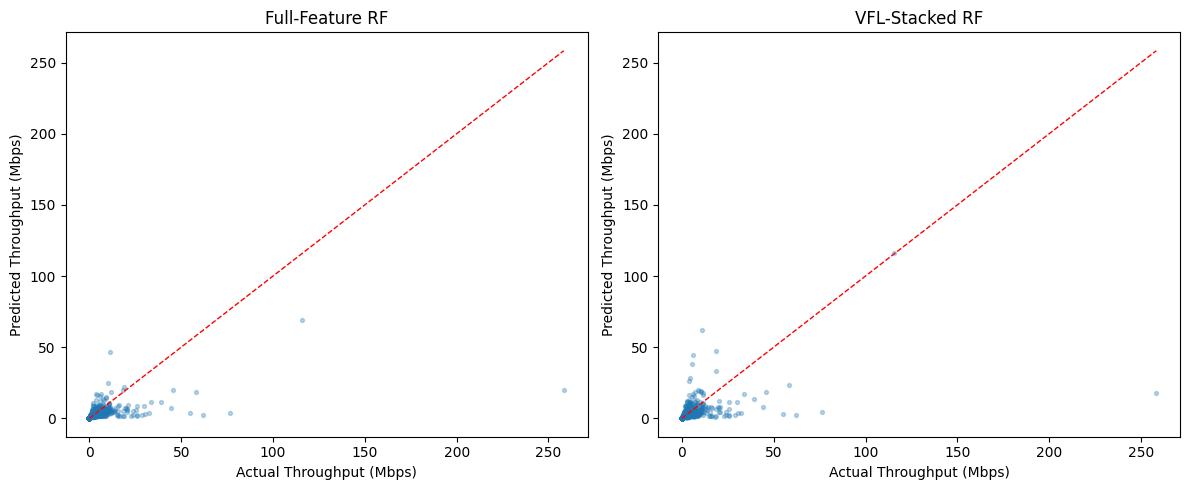

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 2. EVALUATE ON THE UNSEEN VALIDATION SET
# ═══════════════════════════════════════════════════════════════

# --- Stage 1 VFL Prediction ---
ue_val_prob = get_proba(ue_clf, ue_clf_backend, ue_val_s1)
ru_val_prob = get_proba(ru_clf, ru_clf_backend, ru_val_s1)
meta_val_s1 = np.column_stack([ue_val_prob, ru_val_prob])

# Use the trained coordinator to PREDICT (do not fit!)
vfl_val_s1_pred = coord_clf.predict(meta_val_s1).astype(int)

# --- Stage 2 VFL Prediction (for ALL validation rows) ---
X_val_ue_all = val_df[ue_features].astype(np.float32).values 
X_val_ru_all = val_df[ru_features].astype(np.float32).values

ue_val_log_all = predict_rf(ue_reg, ue_reg_backend, X_val_ue_all)
ru_val_log_all = predict_rf(ru_reg, ru_reg_backend, X_val_ru_all)
meta_val_s2_all = np.column_stack([ue_val_log_all, ru_val_log_all])

# Use the trained coordinator to PREDICT (do not fit!)
vfl_val_s2_log_all = coord_reg.predict(meta_val_s2_all)

# --- Combine VFL final throughput ---
vfl_val_final_pred = np.where(vfl_val_s1_pred == 1,
                              np.expm1(vfl_val_s2_log_all), 0.0)
vfl_val_final_pred = np.clip(vfl_val_final_pred, 0, None)

# --- Metrics & Plotting ---
vfl_metrics = eval_regression(y_val_full, vfl_val_final_pred, prefix="VFL_")
full_metrics = val_final_metrics   
# ═══════════════════════════════════════════════════════════════
# VALIDATION COMPARISON: CENTRAL RF vs VFL RF vs LINEAR VFL
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("   VALIDATION COMPARISON (CENTRAL RF | VFL RF | LINEAR VFL)")
print("=" * 65)
print(f"{'Metric':<20} | {'Central RF':<16} | {'VFL-Stacked RF':<16} | {'Linear VFL':<16}")
print("-" * 65)
print(f"{'R² (Log Scale)':<20} | {full_metrics['val_final_R2_log']:16.4f} | {vfl_metrics['VFL_R2_log']:16.4f} | {linear_vfl_metrics['lin_vfl_R2_log']:16.4f}")
print(f"{'RMSE (Log Scale)':<20} | {full_metrics['val_final_RMSE_log']:16.4f} | {vfl_metrics['VFL_RMSE_log']:16.4f} | {linear_vfl_metrics['lin_vfl_RMSE_log']:16.4f}")
print(f"{'MAE (Log Scale)':<20} | {full_metrics['val_final_MAE_log']:16.4f} | {vfl_metrics['VFL_MAE_log']:16.4f} | {linear_vfl_metrics['lin_vfl_MAE_log']:16.4f}")
print("-" * 65)
print(f"{'R² (Raw Scale)':<20} | {full_metrics['val_final_R2_raw']:16.4f} | {vfl_metrics['VFL_R2_raw']:16.4f} | {linear_vfl_metrics['lin_vfl_R2_raw']:16.4f}")
print(f"{'RMSE (Raw Scale)':<20} | {full_metrics['val_final_RMSE_raw']:11.4f} Mbps | {vfl_metrics['VFL_RMSE_raw']:11.4f} Mbps | {linear_vfl_metrics['lin_vfl_RMSE_raw']:11.4f} Mbps")
print(f"{'MAE (Raw Scale)':<20} | {full_metrics['val_final_MAE_raw']:11.4f} Mbps | {vfl_metrics['VFL_MAE_raw']:11.4f} Mbps | {linear_vfl_metrics['lin_vfl_MAE_raw']:11.4f} Mbps")
print("=" * 65)

# --- 3-way scatter plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(y_val_full), size=min(2000, len(y_val_full)), replace=False)

for ax, name, y_pred in zip(axes,
                             ['Central RF', 'VFL-Stacked RF', 'Linear VFL'],
                             [val_final_pred, vfl_val_final_pred, lin_val_final_pred]):
    ax.scatter(y_val_full[sample_idx], y_pred[sample_idx], alpha=0.3, s=8)
    max_val = max(y_val_full[sample_idx].max(), y_pred[sample_idx].max())
    ax.plot([0, max_val], [0, max_val], 'r--', lw=1)
    ax.set_xlabel('Actual Throughput (Mbps)')
    ax.set_ylabel('Predicted Throughput (Mbps)')
    ax.set_title(name)

plt.tight_layout()
plt.show()

rf_ue_s1 = ue_clf
rf_ru_s1 = ru_clf
rf_ue_s2 = ue_reg
rf_ru_s2 = ru_reg

rf_ue_s1_backend = ue_clf_backend
rf_ru_s1_backend = ru_clf_backend
rf_ue_s2_backend = ue_reg_backend
rf_ru_s2_backend = ru_reg_backend

rf_coord_clf = coord_clf
rf_coord_reg = coord_reg

In [ ]:
# ============================================================
# HYBRID LSTM + MLP TWO-STAGE PIPELINE
# Stage 1: active vs idle classifier
# Stage 2: active-only log-throughput regressor
#
# IMPORTANT:
# - Test set is kept untouched until FINAL EVALUATION section.
# - Scaling is fit on train only.
# - Windows never cross User_ID boundary.
# - PRB / Resource_Efficiency / target columns are removed from features.
# ============================================================



# ============================================================
# 0. Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# ============================================================
# 1. Basic configuration
# ============================================================

# Use real percentile target if you already reconstructed it.
TARGET = target
USER_COL = "User_ID"

VAL_FRAC = 0.20

SEQ_LEN = 16       # 16 windows. If each row = 15 seconds, this is 4 minutes.
STRIDE = 4         # reduce overlap and memory
BATCH_SIZE = 256

LSTM_HIDDEN = 32
MLP_HIDDEN = 16
FUSION_HIDDEN = 32
NUM_LAYERS = 1
DROPOUT = 0.20

EPOCHS = 20
PATIENCE = 4
LR = 1e-3
WEIGHT_DECAY = 1e-5

# ============================================================
# 2. Prepare clean dataframe
# ============================================================
train_feats = best_feats
dynamic_trained_cols = [c for c in dynamic_cols if c in train_feats]
static_trained_cols = [c for c in static_cols if c in train_feats]
continous_static_cols = [c for c in static_trained_cols if not c.startswith('State_')]

if (len(newly_generated_lag_cols) != 0):
    dynamic_trained_cols += newly_generated_lag_cols
    
assert(len(train_feats)==len(dynamic_trained_cols)+len(static_trained_cols))

print("dyn:", dynamic_trained_cols)
print("static:", static_trained_cols)

assert TARGET in df.columns, f"Target column {TARGET} not found."
assert USER_COL in df.columns, f"{USER_COL} not found."

# ============================================================
# 5. Fill missing values and scale features using TRAIN ONLY
# ============================================================
# Scale dynamic and static separately
dynamic_scaler = StandardScaler()
static_scaler = StandardScaler()

train_ann_df = train_df.copy()
val_ann_df = val_df.copy()
test_ann_df = test_df.copy()

train_ann_df[dynamic_trained_cols] = dynamic_scaler.fit_transform(train_ann_df[dynamic_trained_cols])
val_ann_df[dynamic_trained_cols] = dynamic_scaler.transform(val_ann_df[dynamic_trained_cols])
test_ann_df[dynamic_trained_cols] = dynamic_scaler.transform(test_ann_df[dynamic_trained_cols])

if continous_static_cols: 
    train_ann_df[continous_static_cols] = static_scaler.fit_transform(train_ann_df[continous_static_cols])
    val_ann_df[continous_static_cols] = static_scaler.transform(val_ann_df[continous_static_cols])
    test_ann_df[continous_static_cols] = static_scaler.transform(test_ann_df[continous_static_cols])
else:
    print("No continous static cols")

dyn: ['SINR_UL', 'BLER', 'SINR_UL_q90', 'BLER_q10', 'Log_Effective_Signal_Robust', 'RU_Current_Load', 'X_meters', 'Y_meters', 'Velocity', 'Crowd_Density_5m']
static: ['State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']
No continous static cols


In [ ]:
# ============================================================
# 6. Dataset
# ============================================================

class HybridSequenceDataset(Dataset):
    """
    Returns:
      x_dynamic: shape (seq_len, dynamic_dim)
      x_static : shape (static_dim,) from last timestep
      y        : classifier label or log-throughput target
      y_raw    : raw throughput target
      end_idx  : end row index inside the provided dataframe
    """

    def __init__(
        self,
        df,
        dynamic_cols,
        static_cols,
        target_col,
        user_col,
        seq_len,
        stride,
        task="classifier",
        active_only=False,
        active_col="Has_Throughput",
    ):
        self.df = df.reset_index(drop=True)
        self.dynamic_cols = dynamic_cols
        self.static_cols = static_cols
        self.target_col = target_col
        self.user_col = user_col
        self.seq_len = seq_len
        self.stride = stride
        self.task = task
        self.active_only = active_only

        self.X_dyn = self.df[dynamic_cols].to_numpy(dtype=np.float32)
        self.X_sta = self.df[static_cols].to_numpy(dtype=np.float32)
        self.y_raw = self.df[target_col].to_numpy(dtype=np.float32)
        self.is_active = self.df[active_col].to_numpy(dtype=np.float32)
        self.uid = self.df[user_col].to_numpy()

        self.windows = self._build_windows()

    def _build_windows(self):
        windows = []
        n = len(self.df)

        i = 0
        while i + self.seq_len <= n:
            start = i
            end = i + self.seq_len - 1

            # Prevent sequence crossing users
            if np.all(self.uid[start:end+1] == self.uid[start]):
                if self.active_only and self.is_active[end] <= 0:
                    i += self.stride
                    continue

                windows.append((start, end))

            i += self.stride

        return windows

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        start, end = self.windows[idx]

        x_dyn = self.X_dyn[start:end + 1]
        x_sta = self.X_sta[end]
        y_value = self.y_raw[end]

        if self.task == "classifier":
            y = np.float32(self.is_active[end])
        elif self.task == "regressor":
            y = np.float32(np.log1p(y_value))
        else:
            raise ValueError("task must be 'classifier' or 'regressor'")

        return (
            torch.from_numpy(x_dyn),
            torch.from_numpy(x_sta),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(y_value, dtype=torch.float32),
            torch.tensor(end, dtype=torch.long),
        )


def make_loader(dataset, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )


# ============================================================
# 7. Model
# ============================================================
class HybridLSTMMLP(nn.Module):
    def __init__(
        self,
        dynamic_dim,
        static_dim,
        lstm_hidden=32,
        mlp_hidden=16,
        fusion_hidden=32,
        num_layers=1,
        dropout=0.2,
    ):
        super().__init__()
        self.static_dim = static_dim # Store to check during forward pass

        self.lstm = nn.LSTM(
            input_size=dynamic_dim,
            hidden_size=lstm_hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Robust check: Only build the MLP if static features actually exist!
        if self.static_dim > 0:
            self.static_mlp = nn.Sequential(
                nn.Linear(static_dim, mlp_hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
            )
            head_input_dim = lstm_hidden + mlp_hidden
        else:
            head_input_dim = lstm_hidden # No static layer padding needed

        self.head = nn.Sequential(
            nn.Linear(head_input_dim, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, 1),
        )

    def forward(self, x_dynamic, x_static):
        lstm_out, _ = self.lstm(x_dynamic)
        lstm_last = lstm_out[:, -1, :]

        # Robust check: Only concatenate if static features exist
        if self.static_dim > 0:
            static_emb = self.static_mlp(x_static)
            x = torch.cat([lstm_last, static_emb], dim=1)
        else:
            x = lstm_last # Pass pure temporal signal
            
        return self.head(x).squeeze(-1)

In [134]:
# ============================================================
# 8. Train and predict helpers
# ============================================================

def train_model(model, train_loader, val_loader, criterion, epochs, lr, patience, weight_decay=0.0):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    best_state = None
    wait = 0

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0

        for x_dyn, x_sta, y, _, _ in train_loader:
            x_dyn = x_dyn.to(device)
            x_sta = x_sta.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            pred = model(x_dyn, x_sta)
            loss = criterion(pred, y)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

            optimizer.step()
            train_loss_sum += loss.item() * x_dyn.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0

        with torch.no_grad():
            for x_dyn, x_sta, y, _, _ in val_loader:
                x_dyn = x_dyn.to(device)
                x_sta = x_sta.to(device)
                y = y.to(device)

                pred = model(x_dyn, x_sta)
                loss = criterion(pred, y)

                val_loss_sum += loss.item() * x_dyn.size(0)

        val_loss = val_loss_sum / len(val_loader.dataset)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
        })

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

            if wait >= patience:
                print(f"Early stopping at epoch {epoch}. Best val_loss={best_val_loss:.5f}")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def predict_model(model, loader):
    model.eval()

    preds = []
    ys = []
    y_raws = []
    end_indices = []

    with torch.no_grad():
        for x_dyn, x_sta, y, y_raw, end_idx in loader:
            x_dyn = x_dyn.to(device)
            x_sta = x_sta.to(device)

            pred = model(x_dyn, x_sta).detach().cpu().numpy()

            preds.append(pred)
            ys.append(y.numpy())
            y_raws.append(y_raw.numpy())
            end_indices.append(end_idx.numpy())

    return {
        "pred": np.concatenate(preds),
        "y": np.concatenate(ys),
        "y_raw": np.concatenate(y_raws),
        "end_idx": np.concatenate(end_indices),
    }


def best_threshold_by_f1(y_true, prob):
    thresholds = np.linspace(0.05, 0.95, 19)

    best_t = 0.5
    best_f1 = -1

    for t in thresholds:
        pred = (prob >= t).astype(int)
        score = f1_score(y_true, pred)

        if score > best_f1:
            best_f1 = score
            best_t = t

    return best_t, best_f1


def safe_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, prob)

In [ ]:
# ============================================================
# 9. Build TRAIN and VAL datasets only
#    Do not create/evaluate test loader yet.
# ============================================================

train_cls_ds = HybridSequenceDataset(
    train_ann_df,
    dynamic_trained_cols,
    static_trained_cols,
    TARGET,
    USER_COL,
    SEQ_LEN,
    STRIDE,
    task="classifier",
    active_only=False,
)

val_cls_ds = HybridSequenceDataset(
    val_ann_df,
    dynamic_trained_cols,
    static_trained_cols,
    TARGET,
    USER_COL,
    SEQ_LEN,
    STRIDE,
    task="classifier",
    active_only=False,
)

train_reg_ds = HybridSequenceDataset(
    train_ann_df,
    dynamic_trained_cols,
    static_trained_cols,
    TARGET,
    USER_COL,
    SEQ_LEN,
    STRIDE,
    task="regressor",
    active_only=True,
)

val_reg_ds = HybridSequenceDataset(
    val_ann_df,
    dynamic_trained_cols,
    static_trained_cols,
    TARGET,
    USER_COL,
    SEQ_LEN,
    STRIDE,
    task="regressor",
    active_only=True,
)

print("\nWindow counts:")
print(f"Classifier train: {len(train_cls_ds):,}")
print(f"Classifier val  : {len(val_cls_ds):,}")
print(f"Regressor train : {len(train_reg_ds):,}")
print(f"Regressor val   : {len(val_reg_ds):,}")


Window counts:
Classifier train: 1,064,000
Classifier val  : 266,000
Regressor train : 338,667
Regressor val   : 91,849


In [136]:
train_cls_loader = make_loader(train_cls_ds, shuffle=True)
val_cls_loader = make_loader(val_cls_ds, shuffle=False)

train_reg_loader = make_loader(train_reg_ds, shuffle=True)
val_reg_loader = make_loader(val_reg_ds, shuffle=False)
# ============================================================
# 10. Stage 1: Train classifier
# ============================================================

print("\n=== STAGE 1: Hybrid LSTM + MLP Classifier ===")

n_pos = sum(train_cls_ds.is_active[end] > 0 for _, end in train_cls_ds.windows)
n_neg = len(train_cls_ds) - n_pos

pos_weight = torch.tensor(n_neg / max(n_pos, 1), dtype=torch.float32).to(device)

print(f"Train active windows: {n_pos:,}")
print(f"Train idle windows  : {n_neg:,}")
print(f"pos_weight          : {pos_weight.item():.4f}")

stage1_model = HybridLSTMMLP(
    dynamic_dim=len(dynamic_trained_cols),
    static_dim=len(static_trained_cols),
    lstm_hidden=LSTM_HIDDEN,
    mlp_hidden=MLP_HIDDEN,
    fusion_hidden=FUSION_HIDDEN,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

criterion_cls = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

start = time.time()

stage1_model, stage1_history = train_model(
    model=stage1_model,
    train_loader=train_cls_loader,
    val_loader=val_cls_loader,
    criterion=criterion_cls,
    epochs=EPOCHS,
    lr=LR,
    patience=PATIENCE,
    weight_decay=WEIGHT_DECAY,
)

stage1_time = time.time() - start

# Validation-only threshold selection
val_cls_out = predict_model(stage1_model, val_cls_loader)

val_logits = val_cls_out["pred"]
val_prob = 1 / (1 + np.exp(-val_logits))
val_y_cls = val_cls_out["y"]

best_threshold, val_best_f1 = best_threshold_by_f1(val_y_cls, val_prob)
val_auc = safe_auc(val_y_cls, val_prob)

print("\nStage 1 validation:")
print(f"Best threshold: {best_threshold:.2f}")
print(f"Val F1        : {val_best_f1:.4f}")
print(f"Val AUC       : {val_auc:.4f}")


=== STAGE 1: Hybrid LSTM + MLP Classifier ===
Train active windows: 338,667
Train idle windows  : 725,333
pos_weight          : 2.1417
Epoch 01 | train_loss=0.02016 | val_loss=0.00080
Epoch 02 | train_loss=0.00098 | val_loss=0.00077
Epoch 03 | train_loss=0.00087 | val_loss=0.00081
Epoch 04 | train_loss=0.00087 | val_loss=0.00082
Epoch 05 | train_loss=0.00082 | val_loss=0.00078
Epoch 06 | train_loss=0.00084 | val_loss=0.00079
Early stopping at epoch 6. Best val_loss=0.00077

Stage 1 validation:
Best threshold: 0.85
Val F1        : 0.9997
Val AUC       : 1.0000


In [ ]:
# ============================================================
# 11. Stage 2: Train active-only log-throughput regressor
# ============================================================

print("\n=== STAGE 2: Hybrid LSTM + MLP Regressor ===")

stage2_model = HybridLSTMMLP(
    dynamic_dim=len(dynamic_trained_cols),
    static_dim=len(static_trained_cols),
    lstm_hidden=LSTM_HIDDEN,
    mlp_hidden=MLP_HIDDEN,
    fusion_hidden=FUSION_HIDDEN,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

criterion_reg = nn.MSELoss()

start = time.time()

stage2_model, stage2_history = train_model(
    model=stage2_model,
    train_loader=train_reg_loader,
    val_loader=val_reg_loader,
    criterion=criterion_reg,
    epochs=EPOCHS,
    lr=LR,
    patience=PATIENCE,
    weight_decay=WEIGHT_DECAY,
)

stage2_time = time.time() - start

# Validation-only Stage 2 metrics
val_reg_out = predict_model(stage2_model, val_reg_loader)

val_pred_log = val_reg_out["pred"]
val_true_log = val_reg_out["y"]

val_pred_raw = np.clip(np.expm1(val_pred_log), 0, None)
val_true_raw = np.expm1(val_true_log)

val_stage2_mae = mean_absolute_error(val_true_raw, val_pred_raw)
val_stage2_rmse = np.sqrt(mean_squared_error(val_true_raw, val_pred_raw))
val_stage2_r2_raw = r2_score(val_true_raw, val_pred_raw)
val_stage2_r2_log = r2_score(val_true_log, val_pred_log)

print("\nStage 2 validation active-only:")
print(f"MAE raw : {val_stage2_mae:.4f}")
print(f"RMSE raw: {val_stage2_rmse:.4f}")
print(f"R2 raw  : {val_stage2_r2_raw:.4f}")
print(f"R2 log  : {val_stage2_r2_log:.4f}")


# ============================================================
# 12. Validation two-stage check
#     This is still validation, not test.
# ============================================================

val_all_reg_ds = HybridSequenceDataset(
    val_ann_df,
    dynamic_trained_cols,
    static_trained_cols,
    TARGET,
    USER_COL,
    SEQ_LEN,
    STRIDE,
    task="regressor",
    active_only=False,
)

val_all_reg_loader = make_loader(val_all_reg_ds, shuffle=False)

val_cls_out = predict_model(stage1_model, val_cls_loader)
val_reg_all_out = predict_model(stage2_model, val_all_reg_loader)

val_prob = 1 / (1 + np.exp(-val_cls_out["pred"]))
val_is_active = val_prob >= best_threshold

val_pred_raw_all = np.clip(np.expm1(val_reg_all_out["pred"]), 0, None)
val_final_pred = np.where(val_is_active, val_pred_raw_all, 0.0)

val_true_raw_all = val_cls_out["y_raw"]

val_final_mae = mean_absolute_error(val_true_raw_all, val_final_pred)
val_final_rmse = np.sqrt(mean_squared_error(val_true_raw_all, val_final_pred))
val_final_r2_raw = r2_score(val_true_raw_all, val_final_pred)
val_final_r2_log = r2_score(np.log1p(val_true_raw_all), np.log1p(val_final_pred))

print("\n=== VALIDATION TWO-STAGE RESULT ===")
print(f"Overall MAE raw : {val_final_mae:.4f}")
print(f"Overall RMSE raw: {val_final_rmse:.4f}")
print(f"Overall R2 raw  : {val_final_r2_raw:.4f}")
print(f"Overall R2 log  : {val_final_r2_log:.4f}")


=== STAGE 2: Hybrid LSTM + MLP Regressor ===
Epoch 01 | train_loss=0.46520 | val_loss=0.39573
Epoch 02 | train_loss=0.39938 | val_loss=0.39032
Epoch 03 | train_loss=0.38871 | val_loss=0.38836
Epoch 04 | train_loss=0.38289 | val_loss=0.38745
Epoch 05 | train_loss=0.37882 | val_loss=0.38240
Epoch 06 | train_loss=0.37624 | val_loss=0.38349
Epoch 07 | train_loss=0.37476 | val_loss=0.38271
Epoch 08 | train_loss=0.37379 | val_loss=0.38371
Epoch 09 | train_loss=0.37257 | val_loss=0.38205
Epoch 10 | train_loss=0.37186 | val_loss=0.38249
Epoch 11 | train_loss=0.37143 | val_loss=0.38437
Epoch 12 | train_loss=0.37101 | val_loss=0.38357
Epoch 13 | train_loss=0.37042 | val_loss=0.38337
Early stopping at epoch 13. Best val_loss=0.38205

Stage 2 validation active-only:
MAE raw : 3.4911
RMSE raw: 10.4446
R2 raw  : 0.1318
R2 log  : 0.3343

=== VALIDATION TWO-STAGE RESULT ===
Overall MAE raw : 1.2058
Overall RMSE raw: 6.1375
Overall R2 raw  : 0.2440
Overall R2 log  : 0.8008


In [141]:
print("\n" + "═" * 70)
print(" 🚀 INITIATING DEEP VERTICAL FEDERATED LEARNING (LSTM + MLP)")
print("═" * 70)

# ============================================================
# 1. SPLIT FEATURES (DYNAMIC VS STATIC FOR EACH PARTY)
# ============================================================
# Intersect your party features with the established static/dynamic lists
ue_dyn = [c for c in dynamic_trained_cols if c in ue_features]
ue_sta = [c for c in static_trained_cols if c in ue_features]

ru_dyn = [c for c in dynamic_trained_cols if c in ru_features]
ru_sta = [c for c in static_trained_cols if c in ru_features]

print(f"UE Features -> Dynamic: {len(ue_dyn)}, Static: {len(ue_sta)}")
print(f"RU Features -> Dynamic: {len(ru_dyn)}, Static: {len(ru_sta)}")

assert(len(ue_dyn)+len(ue_sta)==len(ue_features))
assert(len(ru_dyn)+len(ru_sta)==len(ru_features))


══════════════════════════════════════════════════════════════════════
 🚀 INITIATING DEEP VERTICAL FEDERATED LEARNING (LSTM + MLP)
══════════════════════════════════════════════════════════════════════
UE Features -> Dynamic: 3, Static: 6
RU Features -> Dynamic: 7, Static: 0


In [ ]:
train_base_ann_df = train_ann_df[train_ann_df["User_ID"].isin(base_users)]
train_meta_ann_df = train_ann_df[train_ann_df["User_ID"].isin(meta_users)]

# ============================================================
# 2. CREATE ISOLATED DATASETS
# ============================================================
def build_party_loaders(df, dyn_cols, sta_cols):
    """Return train/val/test-like loaders for a given DataFrame."""
    tr_cls_ds = HybridSequenceDataset(df, dyn_cols, sta_cols, TARGET, USER_COL, SEQ_LEN, STRIDE, "classifier", False)
    tr_reg_ds = HybridSequenceDataset(df, dyn_cols, sta_cols, TARGET, USER_COL, SEQ_LEN, STRIDE, "regressor", True)
    
    tr_cls_loader_shuf = make_loader(tr_cls_ds, shuffle=True)
    tr_cls_loader_noshuf = make_loader(tr_cls_ds, shuffle=False)
    tr_reg_loader_shuf = make_loader(tr_reg_ds, shuffle=True)
    tr_reg_loader_noshuf = make_loader(tr_reg_ds, shuffle=False)
    
    val_cls_ds = HybridSequenceDataset(val_ann_df, dyn_cols, sta_cols, TARGET, USER_COL, SEQ_LEN, STRIDE, "classifier", False)
    val_reg_ds = HybridSequenceDataset(val_ann_df, dyn_cols, sta_cols, TARGET, USER_COL, SEQ_LEN, STRIDE, "regressor", True)
    # Val Stage 2 (ALL rows for final two-stage prediction)
    val_reg_all_ds = HybridSequenceDataset(val_ann_df, dyn_cols, sta_cols, TARGET, USER_COL, SEQ_LEN, STRIDE, "regressor", False)
    
    val_cls_loader = make_loader(val_cls_ds, shuffle=False)
    val_reg_loader = make_loader(val_reg_ds, shuffle=False)
    val_reg_all_loader = make_loader(val_reg_all_ds, shuffle=False)
    
    return {
        "tr_cls": tr_cls_loader_shuf,
        "tr_cls_meta": tr_cls_loader_noshuf,
        "tr_reg": tr_reg_loader_shuf,
        "tr_reg_meta": tr_reg_loader_noshuf,
        "val_cls": val_cls_loader,
        "val_reg_active": val_reg_loader,
        "val_reg_all": val_reg_all_loader,
    }
    
# Create base loaders for training party models
ue_base_loaders = build_party_loaders(train_base_ann_df, ue_dyn, ue_sta)
ru_base_loaders = build_party_loaders(train_base_ann_df, ru_dyn, ru_sta)

# Create meta loaders for generating coordinator training features
ue_meta_loaders = build_party_loaders(train_meta_ann_df, ue_dyn, ue_sta)
ru_meta_loaders = build_party_loaders(train_meta_ann_df, ru_dyn, ru_sta)

In [ ]:
# ============================================================
# 3. TRAIN BASE MODELS (UE & RU)
# ============================================================
def train_party_pipeline(loaders, dyn_cols, sta_cols, party_name):
    print(f"\n--- Training {party_name} Stage 1 (Classifier) ---")
    cls_model = HybridLSTMMLP(len(dyn_cols), len(sta_cols), LSTM_HIDDEN, MLP_HIDDEN, FUSION_HIDDEN, NUM_LAYERS, DROPOUT).to(device)
    cls_model, _ = train_model(cls_model, loaders["tr_cls"], loaders["val_cls"], criterion_cls, EPOCHS, LR, PATIENCE, WEIGHT_DECAY)
    
    print(f"\n--- Training {party_name} Stage 2 (Regressor) ---")
    reg_model = HybridLSTMMLP(len(dyn_cols), len(sta_cols), LSTM_HIDDEN, MLP_HIDDEN, FUSION_HIDDEN, NUM_LAYERS, DROPOUT).to(device)
    reg_model, _ = train_model(reg_model, loaders["tr_reg"], loaders["val_reg_active"], criterion_reg, EPOCHS, LR, PATIENCE, WEIGHT_DECAY)
    
    return cls_model, reg_model

ue_cls_model, ue_reg_model = train_party_pipeline(
    ue_base_loaders, ue_dyn, ue_sta, "UE‑only (base)"
)

ru_cls_model, ru_reg_model = train_party_pipeline(
    ru_base_loaders, ru_dyn, ru_sta, "RU‑only (base)"
)


--- Training UE-Only Stage 1 (Classifier) ---
Epoch 01 | train_loss=0.02219 | val_loss=0.00205
Epoch 02 | train_loss=0.00224 | val_loss=0.00208
Epoch 03 | train_loss=0.00209 | val_loss=0.00206
Epoch 04 | train_loss=0.00206 | val_loss=0.00197
Epoch 05 | train_loss=0.00201 | val_loss=0.00202
Epoch 06 | train_loss=0.00200 | val_loss=0.00198
Epoch 07 | train_loss=0.00192 | val_loss=0.00185
Epoch 08 | train_loss=0.00181 | val_loss=0.00183
Epoch 09 | train_loss=0.00179 | val_loss=0.00196
Epoch 10 | train_loss=0.00175 | val_loss=0.00183
Epoch 11 | train_loss=0.00169 | val_loss=0.00184
Epoch 12 | train_loss=0.00169 | val_loss=0.00180
Epoch 13 | train_loss=0.00171 | val_loss=0.00180
Epoch 14 | train_loss=0.00168 | val_loss=0.00179
Epoch 15 | train_loss=0.00164 | val_loss=0.00178
Epoch 16 | train_loss=0.00161 | val_loss=0.00188
Epoch 17 | train_loss=0.00161 | val_loss=0.00182
Epoch 18 | train_loss=0.00158 | val_loss=0.00176
Epoch 19 | train_loss=0.00162 | val_loss=0.00178
Epoch 20 | train_loss=

In [ ]:
# ============================================================
# 4. TRAIN META-COORDINATORS (LEAK-FREE + ALIGNED)
# ============================================================
print("\n--- Training VFL Meta-Coordinators ---")

# Stage 1 Coordinator (Extract Train Probabilities using UNSHUFFLED loaders)
ue_meta_cls_out = predict_model(ue_cls_model, ue_meta_loaders["tr_cls_meta"])
ru_meta_cls_out = predict_model(ru_cls_model, ru_meta_loaders["tr_cls_meta"])
ue_meta_prob = 1 / (1 + np.exp(-ue_meta_cls_out["pred"]))
ru_meta_prob = 1 / (1 + np.exp(-ru_meta_cls_out["pred"]))

meta_s1 = np.column_stack([ue_meta_prob, ru_meta_prob])
meta_y_s1 = ue_meta_cls_out["y"]


# Stage 2 Coordinator (Extract Train Log-Predictions using UNSHUFFLED loaders)
# Stage 2 log‑throughput predictions
ue_meta_reg_out = predict_model(ue_reg_model, ue_meta_loaders["tr_reg_meta"])
ru_meta_reg_out = predict_model(ru_reg_model, ru_meta_loaders["tr_reg_meta"])
meta_s2 = np.column_stack([ue_meta_reg_out["pred"], ru_meta_reg_out["pred"]])
meta_y_s2 = ue_meta_reg_out["y"]


# --- Train coordinators on the meta set ---
coord_clf = LogisticRegression(random_state=SEED).fit(meta_s1, meta_y_s1)
coord_reg = Ridge(alpha=1.0, solver="lsqr", random_state=SEED).fit(meta_s2, meta_y_s2)



--- Training VFL Meta-Coordinators ---


In [ ]:
# ============================================================
# 5. EVALUATE ON VALIDATION SET
# ============================================================
# Stage 1 VFL Inference
ue_val_cls_out = predict_model(ue_cls_model, ue_meta_loaders["val_cls"])
ru_val_cls_out = predict_model(ru_cls_model, ru_meta_loaders["val_cls"])

ue_val_prob = 1 / (1 + np.exp(-ue_val_cls_out["pred"]))
ru_val_prob = 1 / (1 + np.exp(-ru_val_cls_out["pred"]))

meta_val_s1 = np.column_stack([ue_val_prob, ru_val_prob])
vfl_val_s1_prob = coord_clf.predict_proba(meta_val_s1)[:, 1]

# We use the threshold found previously (best_threshold) or default 0.5
vfl_val_is_active = vfl_val_s1_prob >= best_threshold

# Stage 2 VFL Inference (All Validation Rows)
ue_val_reg_out = predict_model(ue_reg_model, ue_meta_loaders["val_reg_all"])
ru_val_reg_out = predict_model(ru_reg_model, ru_meta_loaders["val_reg_all"])

meta_val_s2 = np.column_stack([ue_val_reg_out["pred"], ru_val_reg_out["pred"]])
vfl_val_s2_log_all = coord_reg.predict(meta_val_s2)

# Combine Logic
vfl_val_pred_raw_all = np.clip(np.expm1(vfl_val_s2_log_all), 0, None)
vfl_val_final_pred = np.where(vfl_val_is_active, vfl_val_pred_raw_all, 0.0)
vfl_true_raw_all = ue_val_cls_out["y_raw"] # Ground truth raw targets

# Calculate VFL Metrics
vfl_final_mae = mean_absolute_error(vfl_true_raw_all, vfl_val_final_pred)
vfl_final_rmse = np.sqrt(mean_squared_error(vfl_true_raw_all, vfl_val_final_pred))
vfl_final_r2_raw = r2_score(vfl_true_raw_all, vfl_val_final_pred)
vfl_final_r2_log = r2_score(np.log1p(vfl_true_raw_all), np.log1p(vfl_val_final_pred))

dl_coord_clf = coord_clf
dl_coord_reg = coord_reg


  🚨 LSTM+MLP VALIDATION: CENTRALIZED FULL vs VFL STACKED 🚨
Metric               | Full-Feature Centralized DL  | VFL-Stacked DL 
----------------------------------------------------------------------
R² (Log Scale)       |                       0.8008 |          0.8018
RMSE (Log Scale)     |                       6.1375 |          6.1442
MAE (Log Scale)      |                       0.1647 |          0.1626
----------------------------------------------------------------------
R² (Raw Scale)       |                       0.2440 |          0.2424
RMSE (Raw Scale)     |                  6.1375 Mbps |     6.1442 Mbps
MAE (Raw Scale)      |                  1.2058 Mbps |     1.1920 Mbps


In [156]:
# --- Alignment Safety Checks ---
assert np.array_equal(ue_val_cls_out["end_idx"], ru_val_cls_out["end_idx"]), "🚨 UE/RU classifier windows are unaligned!"
assert np.array_equal(ue_val_reg_out["end_idx"], ru_val_reg_out["end_idx"]), "🚨 UE/RU regressor windows are unaligned!"
assert np.array_equal(ue_val_cls_out["end_idx"], ue_val_reg_out["end_idx"]), "🚨 VFL Stage 1 & Stage 2 windows are unaligned!"
print("✅ VFL Prediction Arrays are perfectly aligned.")

central_log_true = np.log1p(val_true_raw_all)
central_log_pred = np.log1p(np.clip(val_final_pred, 0, None))

vfl_log_true = np.log1p(vfl_true_raw_all)
vfl_log_pred = np.log1p(np.clip(vfl_val_final_pred, 0, None))

central_rmse_log = np.sqrt(mean_squared_error(central_log_true, central_log_pred))
vfl_rmse_log = np.sqrt(mean_squared_error(vfl_log_true, vfl_log_pred))

central_mae_log = mean_absolute_error(central_log_true, central_log_pred)
vfl_mae_log = mean_absolute_error(vfl_log_true, vfl_log_pred)

print("\n" + "=" * 70)
print("  LSTM+MLP VALIDATION: CENTRALIZED FULL vs VFL STACKED")
print("=" * 70)
print(f"{'Metric':<20} | {'Full-Feature Centralized DL':<28} | {'VFL-Stacked DL':<15}")
print("-" * 70)
print(f"{'R² (Log Scale)':<20} | {val_final_r2_log:28.4f} | {vfl_final_r2_log:15.4f}")
print(f"{'RMSE (Log Scale)':<20} | {central_rmse_log:28.4f} | {vfl_rmse_log:15.4f}")
print(f"{'MAE (Log Scale)':<20} | {central_mae_log:28.4f} | {vfl_mae_log:15.4f}")
print("-" * 70)
print(f"{'R² (Raw Scale)':<20} | {val_final_r2_raw:28.4f} | {vfl_final_r2_raw:15.4f}")
print(f"{'RMSE (Raw Scale)':<20} | {val_final_rmse:23.4f} Mbps | {vfl_final_rmse:10.4f} Mbps")
print(f"{'MAE (Raw Scale)':<20} | {val_final_mae:23.4f} Mbps | {vfl_final_mae:10.4f} Mbps")
print("=" * 70)

✅ VFL Prediction Arrays are perfectly aligned.

  LSTM+MLP VALIDATION: CENTRALIZED FULL vs VFL STACKED
Metric               | Full-Feature Centralized DL  | VFL-Stacked DL 
----------------------------------------------------------------------
R² (Log Scale)       |                       0.8008 |          0.8018
RMSE (Log Scale)     |                       0.3635 |          0.3627
MAE (Log Scale)      |                       0.1647 |          0.1626
----------------------------------------------------------------------
R² (Raw Scale)       |                       0.2440 |          0.2424
RMSE (Raw Scale)     |                  6.1375 Mbps |     6.1442 Mbps
MAE (Raw Scale)      |                  1.2058 Mbps |     1.1920 Mbps



══════════════════════════════════════════════════════════════════════════════════════════
 🏁 INITIATING UNTOUCHED TEST SET EVALUATION (4-WAY SHOWDOWN)
══════════════════════════════════════════════════════════════════════════════════════════
⚠️ rf_test_df_raw not found. Reversing dynamic scaling for RF fairness...
🌲 Extracting Centralized RF Predictions...
🌲 Extracting VFL-Stacked RF Predictions...
🧠 Extracting Centralized DL Predictions...
📡 Extracting VFL-Stacked DL Predictions...
✅ All alignments verified successfully!

🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
  🏆 FINAL UNTOUCHED TEST SET PERFORMANCE SHOWDOWN (4-WAY) 🏆
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
Metric             | Centralized RF   | VFL-Stacked RF   | Centralized DL   | VFL-Stacked DL  
-----------------------------------------------------------------------------------------------
R² (Log Scale)     |           0.5530 |           0.5556 |           0.7229 |           0.7111
RMSE (Log Scale)   |           0.4458 |           0

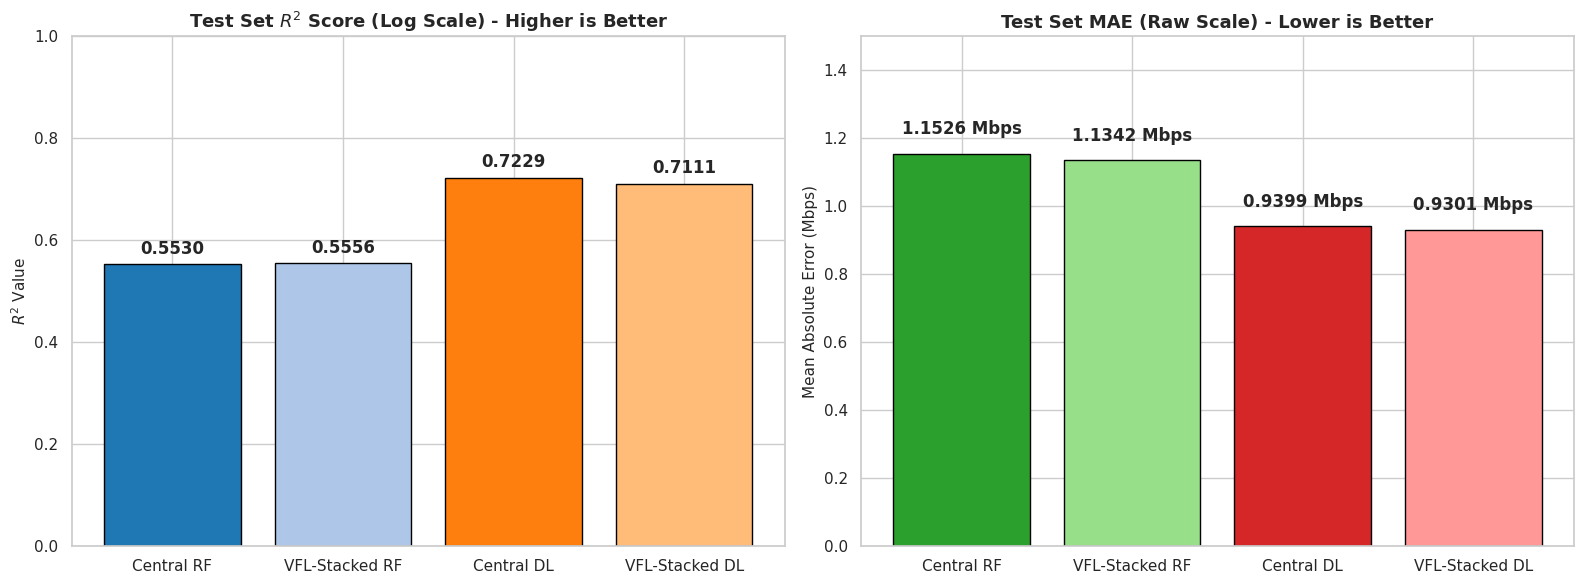

🎉 Analysis Complete! Visual saved to final_vfl_4way_comparison.png


In [ ]:


print("\n" + "═" * 90)
print(" 🏁 INITIATING UNTOUCHED TEST SET EVALUATION (4-WAY SHOWDOWN)")
print("═" * 90)

# ============================================================
# 1. BUILD DEEP LEARNING TEST LOADERS & EXTRACT ALIGNMENT INDICES
# ============================================================
# We build the DL loaders first so we can extract the exact target windows for the RF models
test_cls_ds = HybridSequenceDataset(test_ann_df, dynamic_trained_cols, static_trained_cols, TARGET, USER_COL, SEQ_LEN, STRIDE, "classifier", False)
test_reg_all_ds = HybridSequenceDataset(test_ann_df, dynamic_trained_cols, static_trained_cols, TARGET, USER_COL, SEQ_LEN, STRIDE, "regressor", False)

test_cls_loader = make_loader(test_cls_ds, shuffle=False)
test_reg_all_loader = make_loader(test_reg_all_ds, shuffle=False)

test_indices = test_cls_ds.windows
test_end_indices = np.array([w[1] for w in test_indices])

# ============================================================
# 2. ALIGN TABULAR TEST DATA FOR RANDOM FOREST
# ============================================================
# RF needs the UNSCALED raw data to predict correctly. 
# We try to use rf_test_df_raw if you saved it. If not, we reverse the scaling on test_df.
test_tabular_df = test_df.iloc[test_end_indices].copy()
print("✅ Using unscaled test_df for Random Forest.")

y_test_raw = test_tabular_df[TARGET].values

# ============================================================
# 3. CENTRALIZED RANDOM FOREST PREDICTION
# ============================================================
print("🌲 Extracting Centralized RF Predictions...")
rf_stage1 = joblib.load(f"{dir_name}/{best_exp_name}_FULL_stage1_clf.joblib")
rf_stage2 = joblib.load(f"{dir_name}/{best_exp_name}_FULL_stage2_reg.joblib")

X_rf_cent = test_tabular_df[best_feats].astype(np.float32).values

# to_numpy_safe prevents the KeyError by stripping the Pandas DataFrame shell
rf_cent_s1_prob = to_numpy_safe(rf_stage1.predict_proba(X_rf_cent))[:, 1]
rf_cent_active = rf_cent_s1_prob >= ACTIVE_THRESHOLD
rf_cent_reg_log = to_numpy_safe(rf_stage2.predict(X_rf_cent)).ravel()

rf_cent_final_pred = np.where(rf_cent_active, np.expm1(rf_cent_reg_log), 0.0)
rf_cent_final_pred = np.clip(rf_cent_final_pred, 0, None)

# ============================================================
# 4. VFL STACKED RANDOM FOREST PREDICTION
# ============================================================
print("🌲 Extracting VFL-Stacked RF Predictions...")
X_rf_ue = test_tabular_df[ue_features].astype(np.float32).values
X_rf_ru = test_tabular_df[ru_features].astype(np.float32).values

# Safely map variables in case they were renamed
_ue_clf, _ue_clf_backend = (rf_ue_s1, rf_ue_s1_backend) if 'rf_ue_s1' in locals() else (ue_clf, ue_clf_backend)
_ru_clf, _ru_clf_backend = (rf_ru_s1, rf_ru_s1_backend) if 'rf_ru_s1' in locals() else (ru_clf, ru_clf_backend)
_ue_reg, _ue_reg_backend = (rf_ue_s2, rf_ue_s2_backend) if 'rf_ue_s2' in locals() else (ue_reg, ue_reg_backend)
_ru_reg, _ru_reg_backend = (rf_ru_s2, rf_ru_s2_backend) if 'rf_ru_s2' in locals() else (ru_reg, ru_reg_backend)
_rf_coord_clf = rf_coord_clf if 'rf_coord_clf' in locals() else coord_clf
_rf_coord_reg = rf_coord_reg if 'rf_coord_reg' in locals() else coord_reg

ue_rf_test_prob = get_proba(_ue_clf, _ue_clf_backend, X_rf_ue)
ru_rf_test_prob = get_proba(_ru_clf, _ru_clf_backend, X_rf_ru)

meta_rf_test_s1 = np.column_stack([ue_rf_test_prob, ru_rf_test_prob])
vfl_rf_active = _rf_coord_clf.predict(meta_rf_test_s1).astype(int) == 1

ue_rf_test_log = predict_rf(_ue_reg, _ue_reg_backend, X_rf_ue).ravel()
ru_rf_test_log = predict_rf(_ru_reg, _ru_reg_backend, X_rf_ru).ravel()

meta_rf_test_s2 = np.column_stack([ue_rf_test_log, ru_rf_test_log])
vfl_rf_reg_log = _rf_coord_reg.predict(meta_rf_test_s2)

rf_vfl_final_pred = np.where(vfl_rf_active, np.expm1(vfl_rf_reg_log), 0.0)
rf_vfl_final_pred = np.clip(rf_vfl_final_pred, 0, None)

# ============================================================
# 5. CENTRALIZED DEEP LEARNING (LSTM) PREDICTION
# ============================================================
print("🧠 Extracting Centralized DL Predictions...")
test_cls_out = predict_model(stage1_model, test_cls_loader)
test_reg_out = predict_model(stage2_model, test_reg_all_loader)

assert np.array_equal(test_cls_out["end_idx"], test_end_indices), "Centralized DL Unaligned!"

dl_test_prob = 1 / (1 + np.exp(-test_cls_out["pred"]))
dl_test_active = dl_test_prob >= best_threshold
dl_test_pred_raw = np.clip(np.expm1(test_reg_out["pred"]), 0, None)
dl_cent_final_pred = np.where(dl_test_active, dl_test_pred_raw, 0.0)

# ============================================================
# 6. VFL STACKED DEEP LEARNING (LSTM) PREDICTION
# ============================================================
print("📡 Extracting VFL-Stacked DL Predictions...")
ue_test_cls_ds = HybridSequenceDataset(test_ann_df, ue_dyn, ue_sta, TARGET, USER_COL, SEQ_LEN, STRIDE, "classifier", False)
ue_test_reg_ds = HybridSequenceDataset(test_ann_df, ue_dyn, ue_sta, TARGET, USER_COL, SEQ_LEN, STRIDE, "regressor", False)
ru_test_cls_ds = HybridSequenceDataset(test_ann_df, ru_dyn, ru_sta, TARGET, USER_COL, SEQ_LEN, STRIDE, "classifier", False)
ru_test_reg_ds = HybridSequenceDataset(test_ann_df, ru_dyn, ru_sta, TARGET, USER_COL, SEQ_LEN, STRIDE, "regressor", False)

ue_test_cls_loader = make_loader(ue_test_cls_ds, shuffle=False)
ue_test_reg_loader = make_loader(ue_test_reg_ds, shuffle=False)
ru_test_cls_loader = make_loader(ru_test_cls_ds, shuffle=False)
ru_test_reg_loader = make_loader(ru_test_reg_ds, shuffle=False)

ue_test_cls_out = predict_model(ue_cls_model, ue_test_cls_loader)
ru_test_cls_out = predict_model(ru_cls_model, ru_test_cls_loader)
ue_test_reg_out = predict_model(ue_reg_model, ue_test_reg_loader)
ru_test_reg_out = predict_model(ru_reg_model, ru_test_reg_loader)

assert np.array_equal(test_cls_out["end_idx"], test_reg_out["end_idx"]), "Centralized DL cls/reg unaligned!"

assert np.array_equal(ue_test_cls_out["end_idx"], test_end_indices), "UE classifier test windows unaligned!"
assert np.array_equal(ru_test_cls_out["end_idx"], test_end_indices), "RU classifier test windows unaligned!"
assert np.array_equal(ue_test_reg_out["end_idx"], test_end_indices), "UE regressor test windows unaligned!"
assert np.array_equal(ru_test_reg_out["end_idx"], test_end_indices), "RU regressor test windows unaligned!"

assert np.allclose(y_test_raw, test_cls_out["y_raw"]), "RF/DL test target mismatch!"

# Map DL coordinators safely
_dl_coord_clf = dl_coord_clf if 'dl_coord_clf' in locals() else coord_clf
_dl_coord_reg = dl_coord_reg if 'dl_coord_reg' in locals() else coord_reg

ue_test_prob = 1 / (1 + np.exp(-ue_test_cls_out["pred"]))
ru_test_prob = 1 / (1 + np.exp(-ru_test_cls_out["pred"]))
meta_test_s1 = np.column_stack([ue_test_prob, ru_test_prob])
vfl_dl_test_active = _dl_coord_clf.predict(meta_test_s1) == 1

meta_test_s2 = np.column_stack([ue_test_reg_out["pred"], ru_test_reg_out["pred"]])
vfl_dl_test_reg_log = _dl_coord_reg.predict(meta_test_s2)
vfl_dl_test_pred_raw = np.clip(np.expm1(vfl_dl_test_reg_log), 0, None)
dl_vfl_final_pred = np.where(vfl_dl_test_active, vfl_dl_test_pred_raw, 0.0)

print("✅ All alignments verified successfully!")

# ============================================================
# 7. COMPUTE METRICS & PRINT TABLE
# ============================================================
def get_metrics(y_true, y_pred):
    y_true_log = np.log1p(y_true)
    y_pred_log = np.log1p(y_pred)
    return {
        "R2_log": r2_score(y_true_log, y_pred_log),
        "RMSE_log": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "MAE_log": mean_absolute_error(y_true_log, y_pred_log),
        "R2_raw": r2_score(y_true, y_pred),
        "RMSE_raw": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE_raw": mean_absolute_error(y_true, y_pred),
    }

m_rf_cent = get_metrics(y_test_raw, rf_cent_final_pred)
m_rf_vfl  = get_metrics(y_test_raw, rf_vfl_final_pred)
m_dl_cent = get_metrics(y_test_raw, dl_cent_final_pred)
m_dl_vfl  = get_metrics(y_test_raw, dl_vfl_final_pred)

# ============================================================
# 6.5 LINEAR VFL BASELINE PREDICTION ON TEST
# ============================================================
print("📊 Extracting Linear VFL Predictions...")
X_lin_test = test_tabular_df[ue_features + ru_features].astype(np.float32).values
lin_s1_pred = linear_vfl_clf.predict(X_lin_test)          # 0 or 1
lin_s2_log = linear_vfl_reg.predict(X_lin_test)            # log-throughput
lin_final = np.where(lin_s1_pred == 1, np.expm1(lin_s2_log), 0.0)
lin_final = np.clip(lin_final, 0, None)

m_linear = get_metrics(y_test_raw, lin_final)

# ============================================================
# 7. COMPUTE METRICS & PRINT TABLE (now 5 models)
# ============================================================
print("\n" + "🏆" * 40)
print("   🏆 FINAL UNTOUCHED TEST SET PERFORMANCE (5‑WAY) 🏆")
print("🏆" * 40)
print(f"{'Metric':<18} | {'Central RF':<16} | {'VFL-Stacked RF':<16} | {'Linear VFL':<16} | {'Central DL':<16} | {'VFL-Stacked DL':<16}")
print("-" * 115)
print(f"{'R² (Log Scale)':<18} | {m_rf_cent['R2_log']:16.4f} | {m_rf_vfl['R2_log']:16.4f} | {m_linear['R2_log']:16.4f} | {m_dl_cent['R2_log']:16.4f} | {m_dl_vfl['R2_log']:16.4f}")
print(f"{'RMSE (Log Scale)':<18} | {m_rf_cent['RMSE_log']:16.4f} | {m_rf_vfl['RMSE_log']:16.4f} | {m_linear['RMSE_log']:16.4f} | {m_dl_cent['RMSE_log']:16.4f} | {m_dl_vfl['RMSE_log']:16.4f}")
print(f"{'MAE (Log Scale)':<18} | {m_rf_cent['MAE_log']:16.4f} | {m_rf_vfl['MAE_log']:16.4f} | {m_linear['MAE_log']:16.4f} | {m_dl_cent['MAE_log']:16.4f} | {m_dl_vfl['MAE_log']:16.4f}")
print("-" * 115)
print(f"{'R² (Raw Scale)':<18} | {m_rf_cent['R2_raw']:16.4f} | {m_rf_vfl['R2_raw']:16.4f} | {m_linear['R2_raw']:16.4f} | {m_dl_cent['R2_raw']:16.4f} | {m_dl_vfl['R2_raw']:16.4f}")
print(f"{'RMSE (Raw Scale)':<18} | {m_rf_cent['RMSE_raw']:11.4f} Mbps | {m_rf_vfl['RMSE_raw']:11.4f} Mbps | {m_linear['RMSE_raw']:11.4f} Mbps | {m_dl_cent['RMSE_raw']:11.4f} Mbps | {m_dl_vfl['RMSE_raw']:11.4f} Mbps")
print(f"{'MAE (Raw Scale)':<18} | {m_rf_cent['MAE_raw']:11.4f} Mbps | {m_rf_vfl['MAE_raw']:11.4f} Mbps | {m_linear['MAE_raw']:11.4f} Mbps | {m_dl_cent['MAE_raw']:11.4f} Mbps | {m_dl_vfl['MAE_raw']:11.4f} Mbps")
print("═" * 115)

# ============================================================
# 8. UPDATED BAR CHART (5 models)
# ============================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

models = ['Central RF', 'VFL-Stacked RF', 'Linear VFL', 'Central DL', 'VFL-Stacked DL']
r2_log_vals = [m_rf_cent['R2_log'], m_rf_vfl['R2_log'], m_linear['R2_log'],
               m_dl_cent['R2_log'], m_dl_vfl['R2_log']]
mae_raw_vals = [m_rf_cent['MAE_raw'], m_rf_vfl['MAE_raw'], m_linear['MAE_raw'],
                m_dl_cent['MAE_raw'], m_dl_vfl['MAE_raw']]

# R2 Chart
bars1 = axes[0].bar(models, r2_log_vals,
                    color=['#1f77b4', '#aec7e8', '#9467bd', '#ff7f0e', '#ffbb78'],
                    edgecolor='black')
axes[0].set_title('Test Set $R^2$ Score (Log Scale) - Higher is Better', fontsize=13, fontweight='bold')
axes[0].set_ylabel('$R^2$ Value', fontsize=11)
axes[0].set_ylim(0, 1.0)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f"{bar.get_height():.4f}", ha='center', fontweight='bold')

# MAE Chart
bars2 = axes[1].bar(models, mae_raw_vals,
                    color=['#2ca02c', '#98df8a', '#d62728', '#ff9896', '#8c564b'],
                    edgecolor='black')
axes[1].set_title('Test Set MAE (Raw Scale) - Lower is Better', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error (Mbps)', fontsize=11)
max_mae = max(mae_raw_vals)
axes[1].set_ylim(0, max_mae * 1.3)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max_mae*0.05),
                 f"{bar.get_height():.4f} Mbps", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("final_vfl_5way_comparison.png", dpi=300)
plt.show()

### **3.1: Random Forest Regressor**

### **3.2: Artificial Neural Network**

## **4: Vertical Federated Learning Pipeline**

In this section, we simulate a privacy-preserving VFL environment by splitting the feature space (e.g., User Equipment features vs. Radio Unit features) across distinct local clients before aggregating.

### **4.1: VFL Architecture & Feature Split Setup**

### **4.2: VFL Model Build & Training**

## **5: Cross-Validation & Evaluation**

Here we rigorously test all models using K-Fold Cross Validation and evaluate them using standard regression metrics (RMSE, MAE, R²).

### **5.1: Baseline Models Evaluation (RF vs. ANN)**


### **5.2: VFL vs. Centralized Performance Comparison**


## **6: Full Pipeline & Final Exports**

Consolidating the best-performing models, generating the final comparison plots, and exporting predictions to support the final project report and checkpoint with the Professor.



### **6.1: Feature Importance & Interpretability**

### **6.2: Final Prediction Pipeline**